# AI-Driven Customer Intelligence and Repeat Purchase Prediction for Pakistani E-Commerce

## Business Problem
Pakistani e-commerce platforms face challenges in:
- retaining customers
- identifying high-value buyers
- understanding customer behavior
- reducing cancellation risks

This project builds an AI-driven customer intelligence system that:
1. Segments customers using behavioral analysis
2. Predicts repeat purchases
3. Explains model decisions
4. Generates business recommendations

---

## Project Objectives

- Build a customer intelligence dataset
- Perform business-centric EDA
- Segment customers using KMeans
- Predict repeat purchases using ML
- Explain predictions using SHAP
- Generate actionable business insights

---

## Machine Learning Workflow

Raw Transaction Data
→ Data Cleaning
→ Customer Intelligence Dataset
→ Business EDA
→ Customer Segmentation
→ Repeat Purchase Prediction
→ Explainability AI
→ Business Recommendations

---

## Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- SHAP

In [4]:
# SECTION 2 — IMPORT LIBRARIES

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Explainability
import shap

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)

# Plot Style
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
# SECTION 3 — LOAD DATASET

# Load dataset
df = pd.read_csv("/content/pakecommerce.csv")

# Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (245358, 21)


In [6]:
# Display first 5 rows
df.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,discount_amount,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131,complete,07/01/2016,kreations_YI 06-L,1950.0,1,1950.0,100147443,Women's Fashion,\N,0.0,cod,07/01/2016,#REF!,"1,950",2016.0,7.0,2016-7,Jul-16,FY17,1.0
1,211133,canceled,07/01/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,240.0,100147444,Beauty & Grooming,\N,0.0,cod,07/01/2016,Gross,240,2016.0,7.0,2016-7,Jul-16,FY17,2.0
2,211134,canceled,07/01/2016,Ego_UP0017-999-MR0,2450.0,1,2450.0,100147445,Women's Fashion,\N,0.0,cod,07/01/2016,Gross,"2,450",2016.0,7.0,2016-7,Jul-16,FY17,3.0
3,211135,complete,07/01/2016,kcc_krone deal,360.0,1,60.0,100147446,Beauty & Grooming,R-FSD-52352,300.0,cod,07/01/2016,Net,360,2016.0,7.0,2016-7,Jul-16,FY17,4.0
4,211136,order_refunded,07/01/2016,BK7010400AG,555.0,2,1110.0,100147447,Soghaat,\N,0.0,cod,07/01/2016,Valid,"1,110",2016.0,7.0,2016-7,Jul-16,FY17,5.0


In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245358 entries, 0 to 245357
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                245358 non-null  int64  
 1   status                 245358 non-null  object 
 2   created_at             245358 non-null  object 
 3   sku                    245342 non-null  object 
 4   price                  245358 non-null  float64
 5   qty_ordered            245358 non-null  int64  
 6   grand_total            245358 non-null  float64
 7   increment_id           245358 non-null  object 
 8   category_name_1        245357 non-null  object 
 9   sales_commission_code  245353 non-null  object 
 10  discount_amount        245357 non-null  float64
 11  payment_method         245357 non-null  object 
 12  Working Date           245357 non-null  object 
 13  BI Status              245357 non-null  object 
 14   MV                    245357 non-nu

In [8]:
# Statistical Summary
df.describe()

,item_id,price,qty_ordered,grand_total,discount_amount,Year,Month,Customer ID
count,245358.000000,245358.000000,245358.000000,2.453580e+05,245357.000000,245357.000000,245357.000000,245357.000000
mean,364456.703519,4522.770445,1.201832,6.363391e+03,266.367952,2016.454228,7.299906,18571.417975
std,88637.938687,12037.335334,5.330790,9.004670e+04,1245.537060,0.497902,3.542267,15489.236701
min,211131.000000,0.000000,1.000000,-1.000000e+01,-599.500000,2016.000000,1.000000,1.000000
25%,287716.250000,306.000000,1.000000,5.600000e+02,0.000000,2016.000000,4.000000,4923.000000
50%,364343.500000,729.000000,1.000000,1.278000e+03,0.000000,2016.000000,8.000000,14802.000000
75%,443512.750000,1999.000000,1.000000,3.894000e+03,42.750000,2017.000000,11.000000,30991.000000
max,514463.000000,479000.000000,1000.000000,1.788800e+07,90300.000000,2017.000000,12.000000,51141.000000


In [9]:
# Display all column names
df.columns.tolist()

['item_id',
 'status',
 'created_at',
 'sku',
 'price',
 'qty_ordered',
 'grand_total',
 'increment_id',
 'category_name_1',
 'sales_commission_code',
 'discount_amount',
 'payment_method',
 'Working Date',
 'BI Status',
 ' MV ',
 'Year',
 'Month',
 'Customer Since',
 'M-Y',
 'FY',
 'Customer ID']

# Section 4 Data Cleaning

In [10]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Display cleaned column names
df.columns.tolist()

['item_id',
 'status',
 'created_at',
 'sku',
 'price',
 'qty_ordered',
 'grand_total',
 'increment_id',
 'category_name_1',
 'sales_commission_code',
 'discount_amount',
 'payment_method',
 'working_date',
 'bi_status',
 'mv',
 'year',
 'month',
 'customer_since',
 'm-y',
 'fy',
 'customer_id']

In [11]:
# Missing values count
missing_values = df.isnull().sum()

# Display columns with missing values
missing_values[missing_values > 0]

,0
sku,16
category_name_1,1
sales_commission_code,5
discount_amount,1
payment_method,1
working_date,1
bi_status,1
mv,1
year,1
month,1


# Missing Values Heatmap

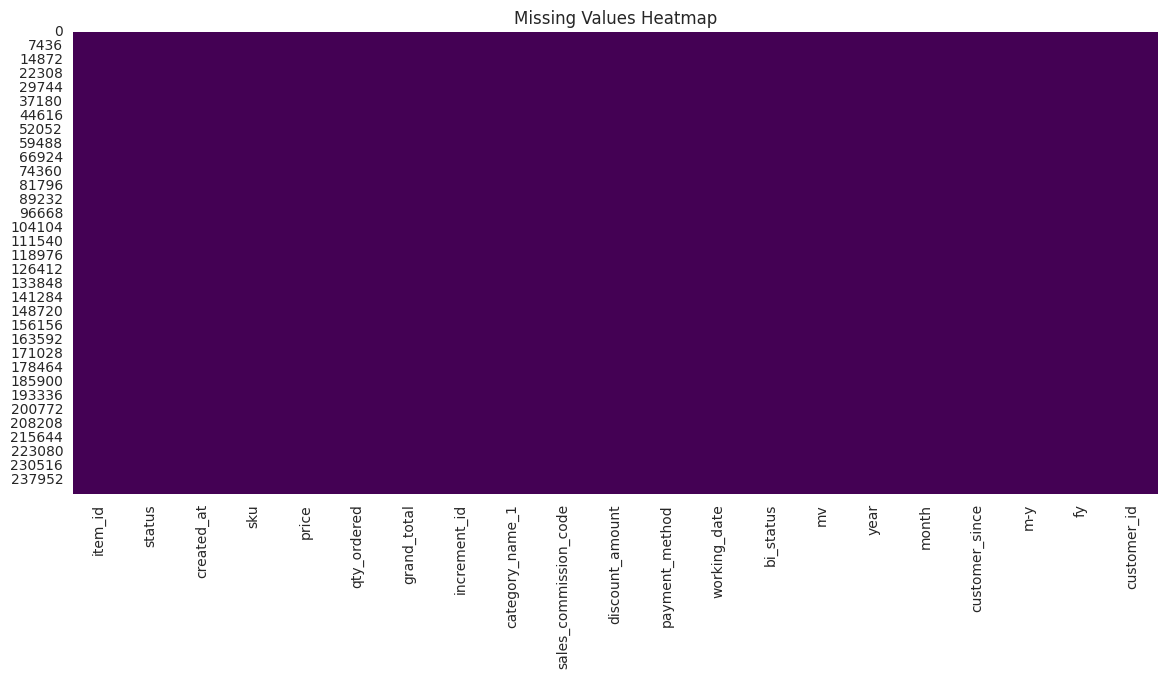

In [12]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

# Graph 2 Missing Value Percentage

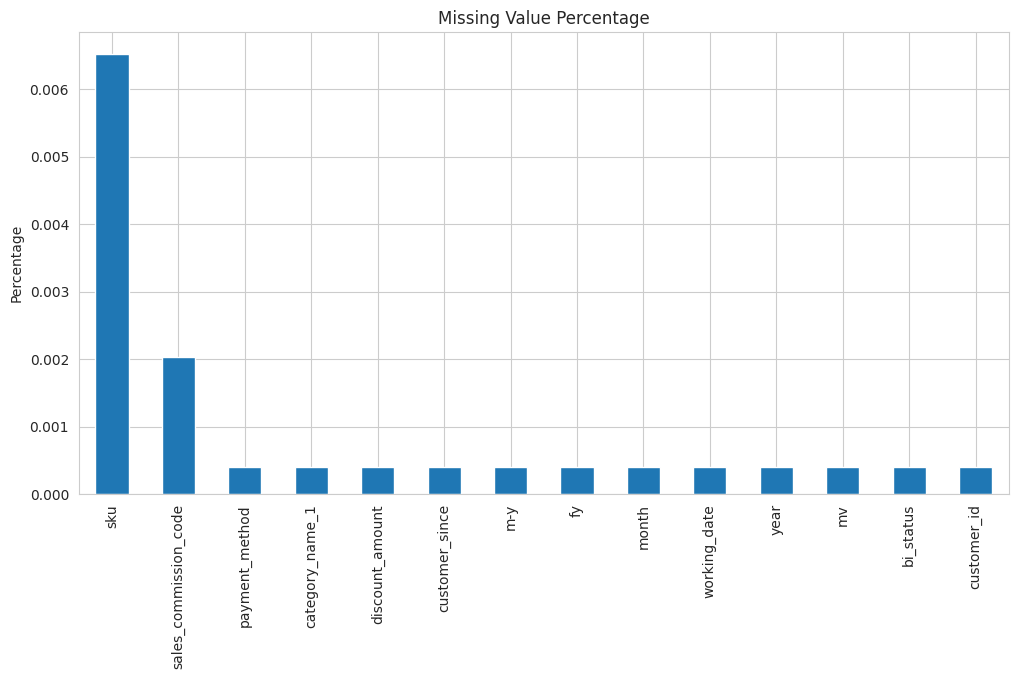

In [13]:
missing_percent = (
    df.isnull()
      .mean()
      .sort_values(ascending=False) * 100
)

missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(12,6))

missing_percent.plot(kind='bar')

plt.title("Missing Value Percentage")
plt.ylabel("Percentage")

plt.show()

## Checking Duplicates

In [14]:
# Duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [15]:
# We dont have duplicates but we should run the code which will remove any duplicates if they exist in the future
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (245358, 21)


In [16]:
# Checking data types again after cleaning
df.dtypes

,0
item_id,int64
status,object
created_at,object
sku,object
price,float64
qty_ordered,int64
grand_total,float64
increment_id,object
category_name_1,object
sales_commission_code,object


In [17]:
# Find date-related columns
[col for col in df.columns if 'date' in col or 'created' in col]

['created_at', 'working_date']

In [18]:
# Cleaning order status
df['status'] = (
    df['status']
      .astype(str)
      .str.lower()
      .str.strip()
)

In [19]:
# Check unique values in status column
df['status'].value_counts()

,count
status,
complete,125403
canceled,74030
order_refunded,26924
received,14578
refund,3919
closed,318
paid,163
fraud,10
holded,6


# Removing invalid Transactions

In [20]:
df.columns

Index(['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered',
       'grand_total', 'increment_id', 'category_name_1',
       'sales_commission_code', 'discount_amount', 'payment_method',
       'working_date', 'bi_status', 'mv', 'year', 'month', 'customer_since',
       'm-y', 'fy', 'customer_id'],
      dtype='object')

In [21]:
# Keep positive transactions only
df = df[df['grand_total'] > 0]

In [22]:
# Payment methods
df['payment_method'].value_counts()

,count
payment_method,
cod,137408
Payaxis,53576
jazzwallet,24653
Easypay,10082
jazzvoucher,9248
Easypay_MA,2184
easypay_voucher,1164
ublcreditcard,882
cashatdoorstep,723


# Basic Data Summary

In [23]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Total Rows: 241547
Total Columns: 21

Missing Values:
19

Duplicate Rows:
0


# Graph 3 Order Status Distribution

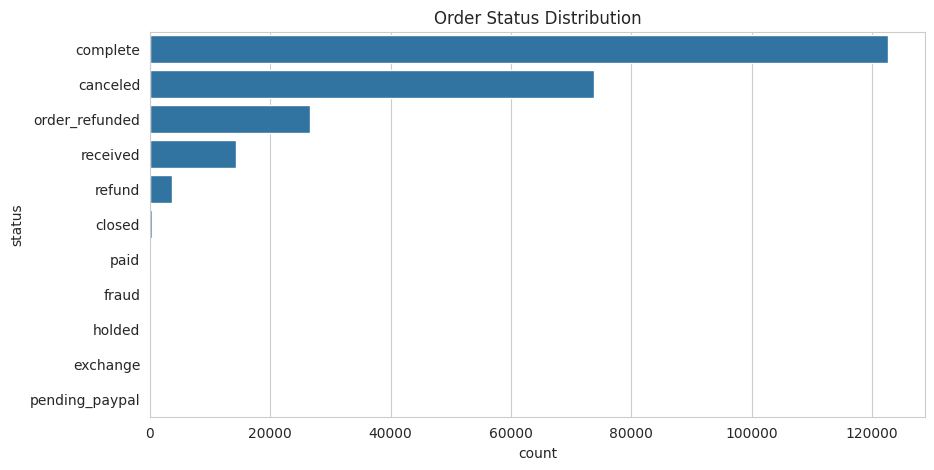

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=df['status'],
    order=df['status'].value_counts().index
)

plt.title("Order Status Distribution")

plt.show()

# GRAPH 4 Payment Method Distribution

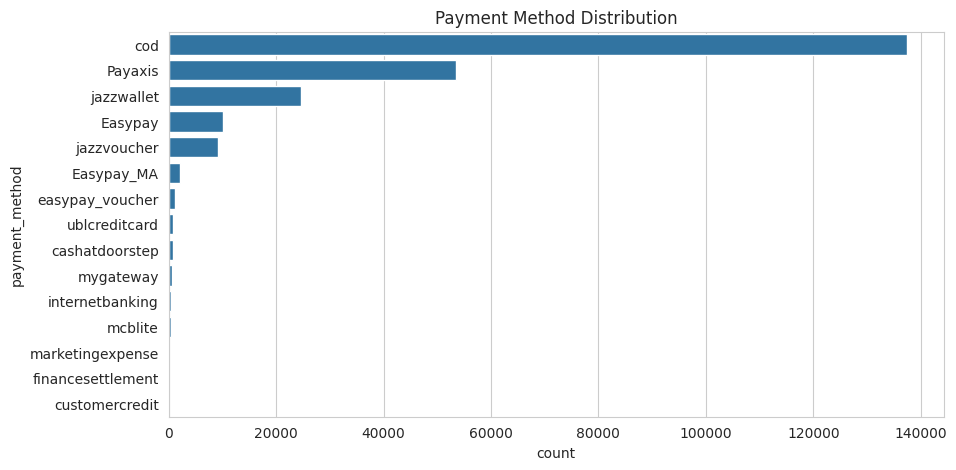

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=df['payment_method'],
    order=df['payment_method'].value_counts().index
)

plt.title("Payment Method Distribution")

plt.show()

# SECTION 5 CUSTOMER INTELLIGENCE DATASET CREATION

Where I am going to create:

RFM features

behavioral features

category features

time features

repeat purchase target

Here I will convert the Raw Dataset to Customer Intelligence Dataset Right now the dataset look like 1 Row = 1 Transaction but i will create 1 Row = 1 Customer

In [26]:
# Display all columns
df.columns.tolist()

['item_id',
 'status',
 'created_at',
 'sku',
 'price',
 'qty_ordered',
 'grand_total',
 'increment_id',
 'category_name_1',
 'sales_commission_code',
 'discount_amount',
 'payment_method',
 'working_date',
 'bi_status',
 'mv',
 'year',
 'month',
 'customer_since',
 'm-y',
 'fy',
 'customer_id']

In [27]:
# Create copy of dataset
data = df.copy()

In [28]:
# Create reference date
reference_date = data['created_at'].max()

print("Reference Date:", reference_date)

Reference Date: 9/30/2016


# Creating RFM Features

RECENCY

Question:

How recently did customer purchase?

FREQUENCY

Question:

How often does customer purchase?

MONETARY

Question:

How much money does customer spend?

# Creating RFM Features

In [29]:
# ensure created_at is datetime
data['created_at'] = pd.to_datetime(data['created_at'], errors='coerce')

# drop rows with missing customer_id or created_at
data = data.dropna(subset=['customer_id', 'created_at'])

# recompute reference date
reference_date = data['created_at'].max()

rfm = (
    data.groupby('customer_id')
        .agg(
            recency=('created_at', lambda x: (reference_date - x.max()).days),
            frequency=('increment_id', 'count'),
            monetary=('grand_total', 'sum')
        )
        .reset_index()
)

rfm.head()


,customer_id,recency,frequency,monetary
0,1.0,349,1,1950.00
1,2.0,202,2,510.00
2,3.0,27,5,7430.00
3,4.0,9,381,2122790.55
4,5.0,349,1,1110.00


# Creating Behaviroul Features

In [30]:
# Average Order Value
avg_order_value = data.groupby('customer_id')['grand_total'].mean().reset_index()

avg_order_value.columns = [
    'customer_id',
    'avg_order_value'
]

In [31]:
# Total items purchased
total_items = data.groupby('customer_id')['qty_ordered'].sum().reset_index()

total_items.columns = [
    'customer_id',
    'total_items'
]

In [32]:
# Average basket size
basket_size = data.groupby('customer_id')['qty_ordered'].mean().reset_index()

basket_size.columns = [
    'customer_id',
    'avg_basket_size'
]

In [33]:
# COD flag
data['is_cod'] = np.where(
    data['payment_method'].str.lower().str.contains('cod'),
    1,
    0
)

In [34]:
# COD ratio
cod_ratio = data.groupby('customer_id')['is_cod'].mean().reset_index()

cod_ratio.columns = [
    'customer_id',
    'cod_ratio'
]

In [35]:
# Cancellation flag
data['is_cancelled'] = np.where(
    data['status'].str.contains('cancel'),
    1,
    0
)

In [36]:
# Cancellation ratio
cancel_ratio = data.groupby('customer_id')['is_cancelled'].mean().reset_index()

cancel_ratio.columns = [
    'customer_id',
    'cancel_ratio'
]

In [37]:
# Day of week
data['day_of_week'] = data['created_at'].dt.dayofweek

# Weekend flag
data['is_weekend'] = np.where(
    data['day_of_week'] >= 5,
    1,
    0
)

In [38]:
# Weekend ratio
weekend_ratio = data.groupby('customer_id')['is_weekend'].mean().reset_index()

weekend_ratio.columns = [
    'customer_id',
    'weekend_ratio'
]

In [39]:
# Order hour
data['order_hour'] = data['created_at'].dt.hour

# Night orders flag
data['is_night_order'] = np.where(
    (data['order_hour'] >= 22) |
    (data['order_hour'] <= 6),
    1,
    0
)

In [40]:
# Night order ratio
night_ratio = data.groupby('customer_id')['is_night_order'].mean().reset_index()

night_ratio.columns = [
    'customer_id',
    'night_order_ratio'
]

# Creating Category Features

In [41]:
# Favorite category
favorite_category = (
    data.groupby(['customer_id', 'category_name_1'])
        .size()
        .reset_index(name='count')
)

favorite_category = (
    favorite_category.sort_values(
        ['customer_id', 'count'],
        ascending=[True, False]
    )
    .drop_duplicates('customer_id')
)

favorite_category = favorite_category[
    ['customer_id', 'category_name_1']
]

favorite_category.columns = [
    'customer_id',
    'favorite_category'
]

favorite_category.head()

,customer_id,favorite_category
0,1.0,Women's Fashion
1,2.0,Beauty & Grooming
3,3.0,Men's Fashion
13,4.0,Men's Fashion
21,5.0,Soghaat


In [42]:
# Category diversity
category_diversity = (
    data.groupby('customer_id')['category_name_1']
        .nunique()
        .reset_index()
)

category_diversity.columns = [
    'customer_id',
    'category_diversity'
]

# Merging all created Features

In [43]:
# Master customer dataset
customer_df = rfm.copy()

In [44]:
# Merge behavioral features
customer_df = customer_df.merge(
    avg_order_value,
    on='customer_id',
    how='left'
)

customer_df = customer_df.merge(
    total_items,
    on='customer_id',
    how='left'
)

customer_df = customer_df.merge(
    basket_size,
    on='customer_id',
    how='left'
)

customer_df = customer_df.merge(
    cod_ratio,
    on='customer_id',
    how='left'
)

customer_df = customer_df.merge(
    cancel_ratio,
    on='customer_id',
    how='left'
)

customer_df = customer_df.merge(
    weekend_ratio,
    on='customer_id',
    how='left'
)

customer_df = customer_df.merge(
    night_ratio,
    on='customer_id',
    how='left'
)

customer_df = customer_df.merge(
    category_diversity,
    on='customer_id',
    how='left'
)

customer_df = customer_df.merge(
    favorite_category,
    on='customer_id',
    how='left'
)

# Final Dataset

In [45]:
# Display shape
print(customer_df.shape)

# First rows
customer_df.head()

(50969, 13)


,customer_id,recency,frequency,monetary,avg_order_value,total_items,avg_basket_size,cod_ratio,cancel_ratio,weekend_ratio,night_order_ratio,category_diversity,favorite_category
0,1.0,349,1,1950.00,1950.00000,1,1.000000,1.000000,0.000000,0.000000,1.0,1,Women's Fashion
1,2.0,202,2,510.00,255.00000,2,1.000000,0.500000,1.000000,0.000000,1.0,2,Beauty & Grooming
2,3.0,27,5,7430.00,1486.00000,5,1.000000,1.000000,0.200000,0.000000,1.0,3,Men's Fashion
3,4.0,9,381,2122790.55,5571.62874,444,1.165354,0.690289,0.244094,0.125984,1.0,15,Men's Fashion
4,5.0,349,1,1110.00,1110.00000,2,2.000000,1.000000,0.000000,0.000000,1.0,1,Soghaat


# Creating Target

In [46]:
# Repeat purchase target
customer_df['repeat_purchase'] = np.where(
    customer_df['frequency'] > 1,
    1,
    0
)

In [47]:
# Target distribution
customer_df['repeat_purchase'].value_counts()

,count
repeat_purchase,
1,25927
0,25042


In [48]:
# Missing values
customer_df.isnull().sum()

,0
customer_id,0
recency,0
frequency,0
monetary,0
avg_order_value,0
total_items,0
avg_basket_size,0
cod_ratio,0
cancel_ratio,0
weekend_ratio,0


In [49]:
# Fill missing favorite category
customer_df['favorite_category'] = (
    customer_df['favorite_category']
        .fillna('Unknown')
)

# Saving our Intelligence Dataset

In [50]:
# Save customer intelligence dataset
customer_df.to_csv(
    "customer_intelligence_dataset.csv",
    index=False
)

# Business Centric EDA
1 Dataset Overview

2 RFM Analysis

3 Payment Behavior Analysis

4 Category Analysis

5 Time-Based Analysis

6 Behavioral Feature Analysis

7 Correlation Analysis

8 Target Variable Analysis

In [51]:
# Create EDA copy
eda_df = customer_df.copy()

# GRAPH 5 Repeat Purchase Distribution

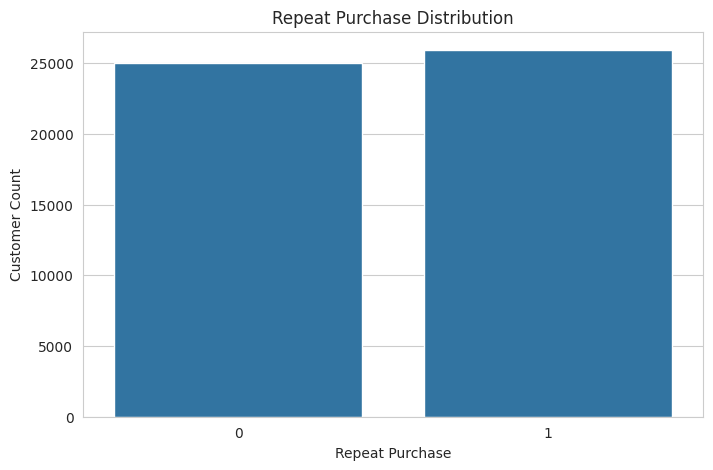

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='repeat_purchase',
    data=eda_df
)

plt.title("Repeat Purchase Distribution")
plt.xlabel("Repeat Purchase")
plt.ylabel("Customer Count")

plt.show()

In [53]:
repeat_rate = eda_df['repeat_purchase'].mean() * 100

print(f"Repeat Purchase Rate: {repeat_rate:.2f}%")

Repeat Purchase Rate: 50.87%


# GRAPH 6 Monetary Distribution

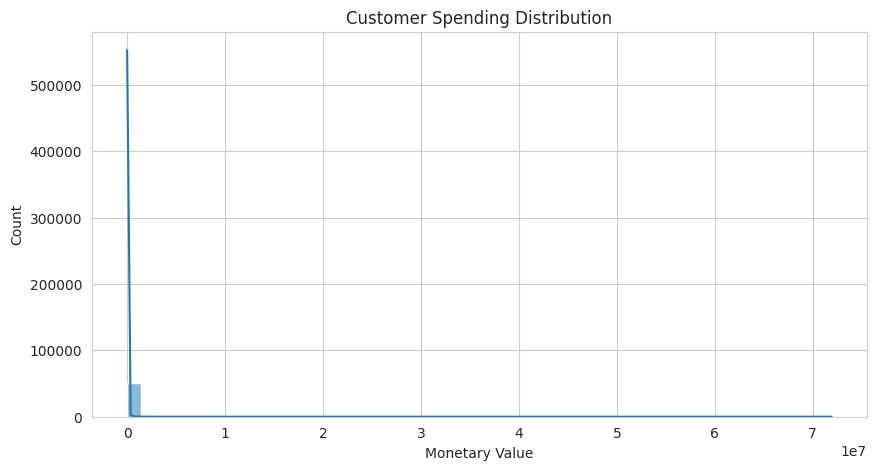

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['monetary'],
    bins=50,
    kde=True
)

plt.title("Customer Spending Distribution")
plt.xlabel("Monetary Value")

plt.show()

# GRAPH 7 Monetary Boxplot

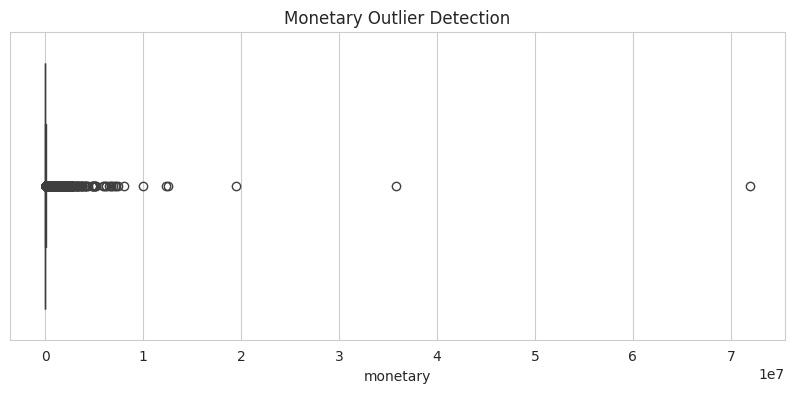

In [55]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=eda_df['monetary']
)

plt.title("Monetary Outlier Detection")

plt.show()

# RFM Analysis

# GRAPH 8 Recency Distribution

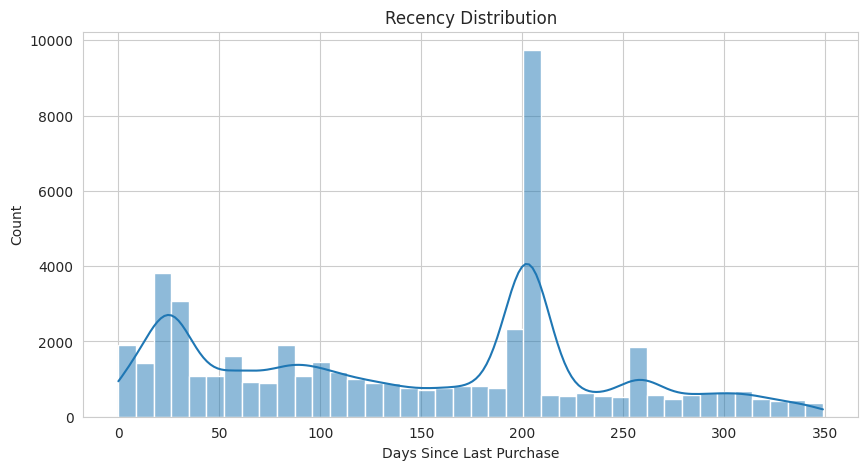

In [56]:
plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['recency'],
    bins=40,
    kde=True
)

plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")

plt.show()

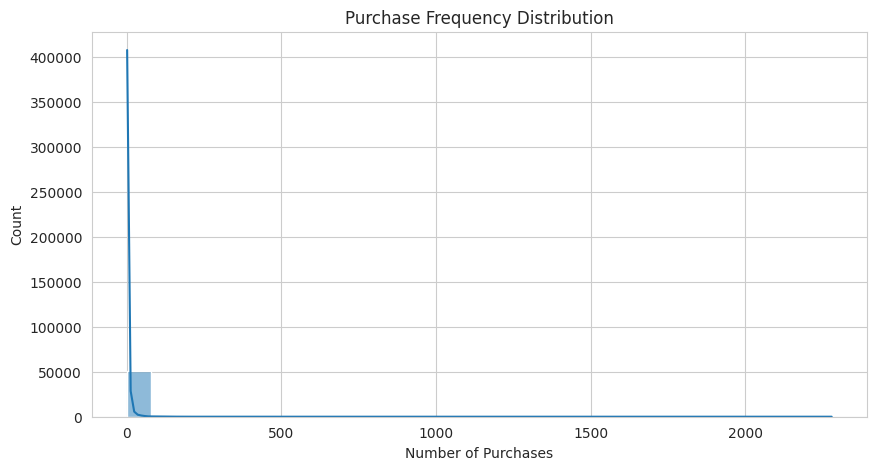

In [57]:
# ============================================
# GRAPH 9 — Frequency Distribution
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['frequency'],
    bins=30,
    kde=True
)

plt.title("Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")

plt.show()

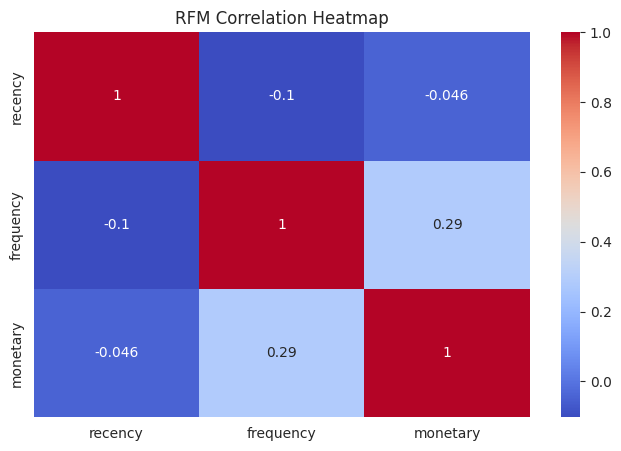

In [58]:
# ============================================
# GRAPH 10 — RFM Correlation Heatmap
# ============================================

rfm_features = eda_df[
    ['recency', 'frequency', 'monetary']
]

plt.figure(figsize=(8,5))

sns.heatmap(
    rfm_features.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("RFM Correlation Heatmap")

plt.show()

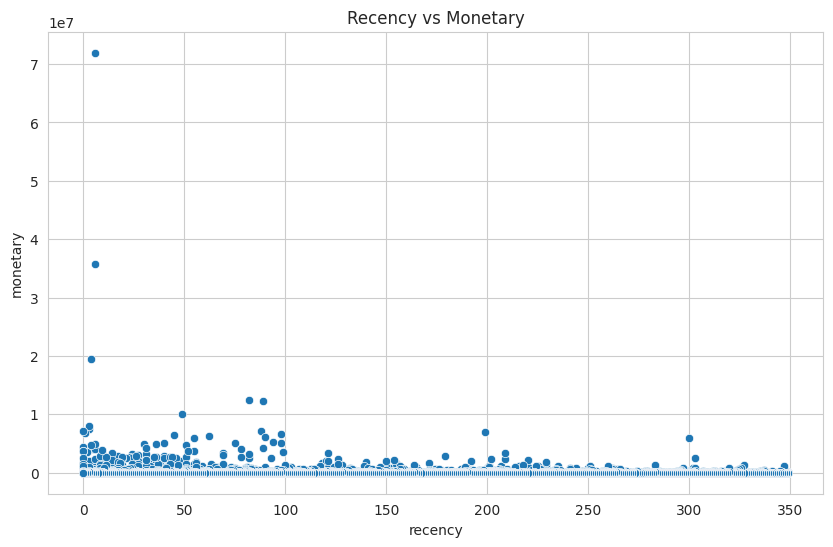

In [59]:
# ============================================
# GRAPH 11 — Recency vs Monetary
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='recency',
    y='monetary',
    data=eda_df
)

plt.title("Recency vs Monetary")

plt.show()

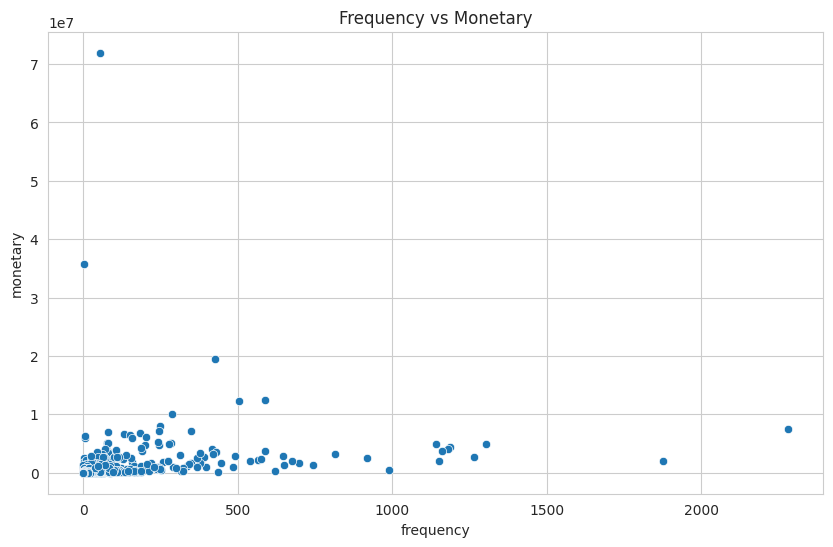

In [60]:
# ============================================
# GRAPH 12 — Frequency vs Monetary
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='frequency',
    y='monetary',
    data=eda_df
)

plt.title("Frequency vs Monetary")

plt.show()

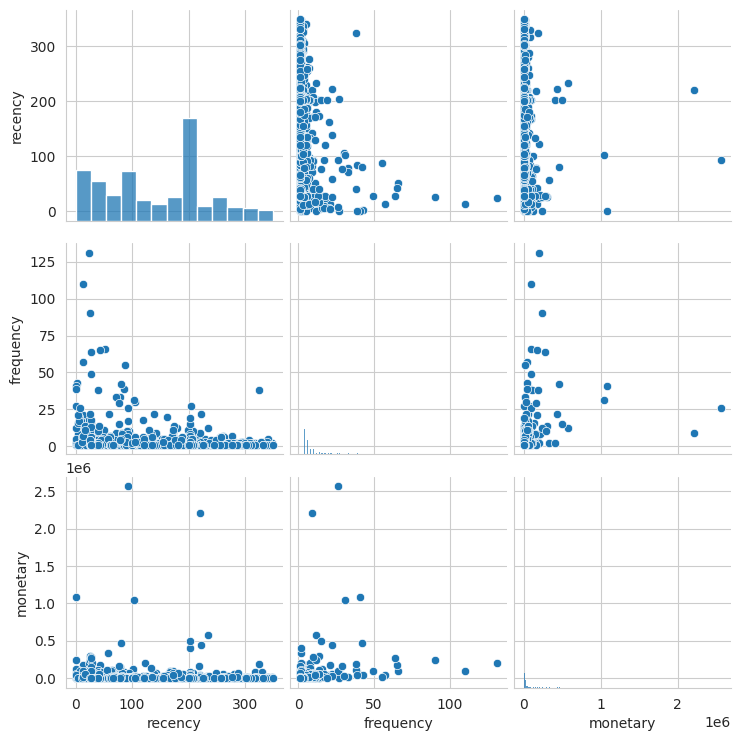

In [61]:
# ============================================
# GRAPH 13 — RFM Pairplot
# ============================================

sample_df = eda_df.sample(
    min(1000, len(eda_df)),
    random_state=42
)

sns.pairplot(
    sample_df[
        ['recency', 'frequency', 'monetary']
    ]
)

plt.show()

# Payment Behaviour Analysis

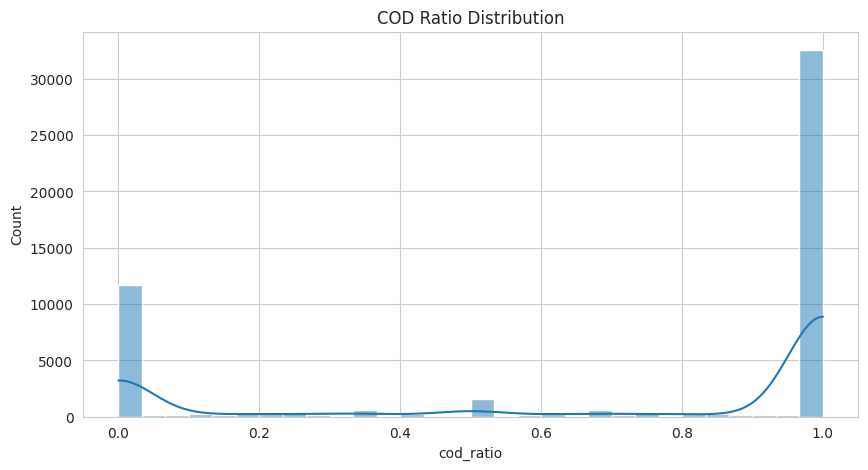

In [62]:
# ============================================
# GRAPH 14 — COD Ratio Distribution
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['cod_ratio'],
    bins=30,
    kde=True
)

plt.title("COD Ratio Distribution")

plt.show()

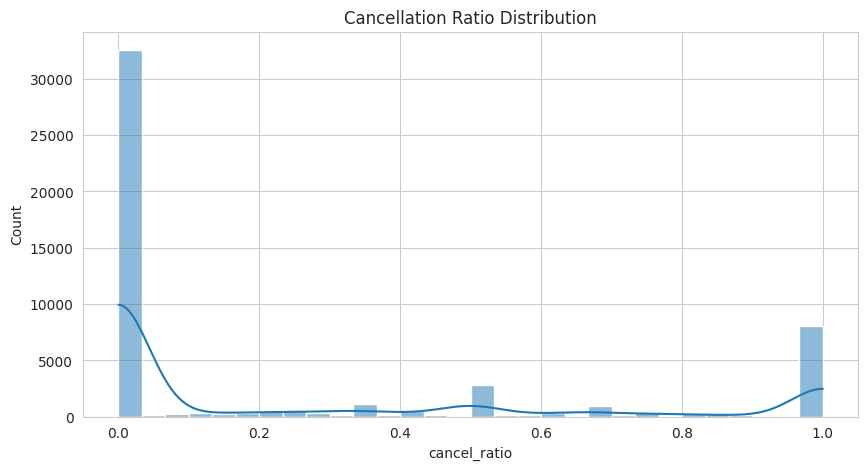

In [63]:
# ============================================
# GRAPH 15 — Cancellation Ratio Distribution
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['cancel_ratio'],
    bins=30,
    kde=True
)

plt.title("Cancellation Ratio Distribution")

plt.show()

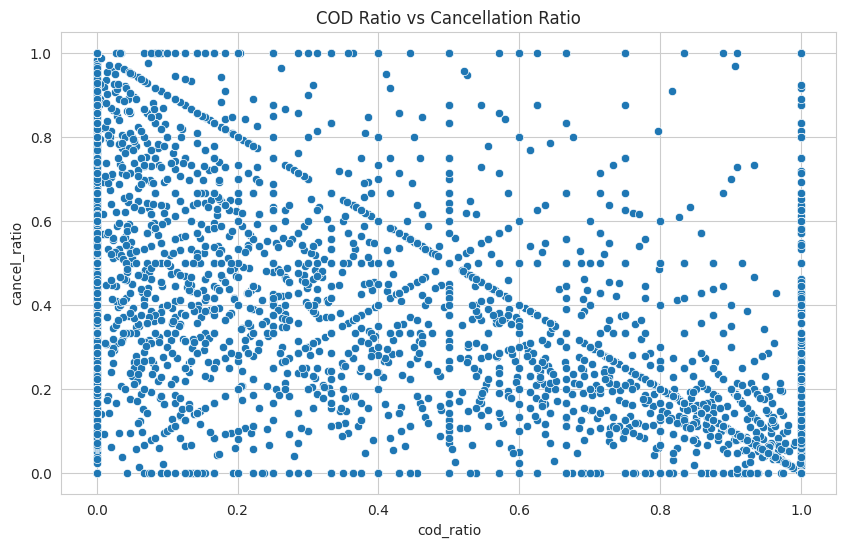

In [64]:
# ============================================
# GRAPH 16 — COD Ratio vs Cancellation
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='cod_ratio',
    y='cancel_ratio',
    data=eda_df
)

plt.title("COD Ratio vs Cancellation Ratio")

plt.show()

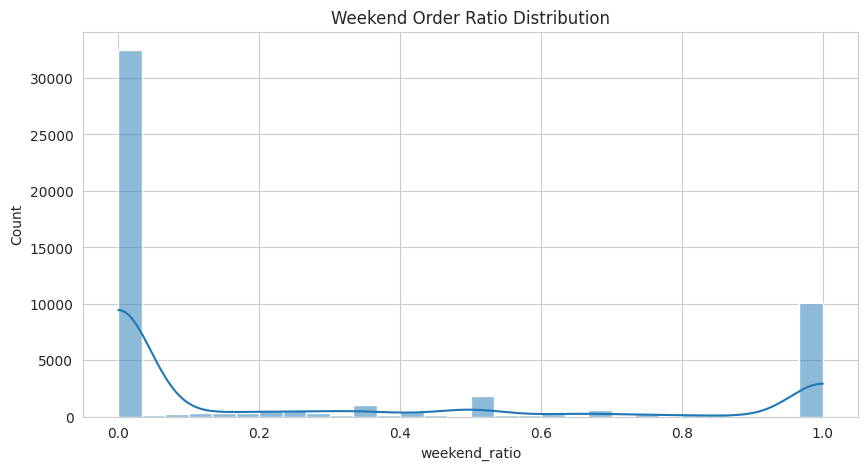

In [65]:
# ============================================
# GRAPH 17 — Weekend Order Ratio
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['weekend_ratio'],
    bins=30,
    kde=True
)

plt.title("Weekend Order Ratio Distribution")

plt.show()

# Category Analysis

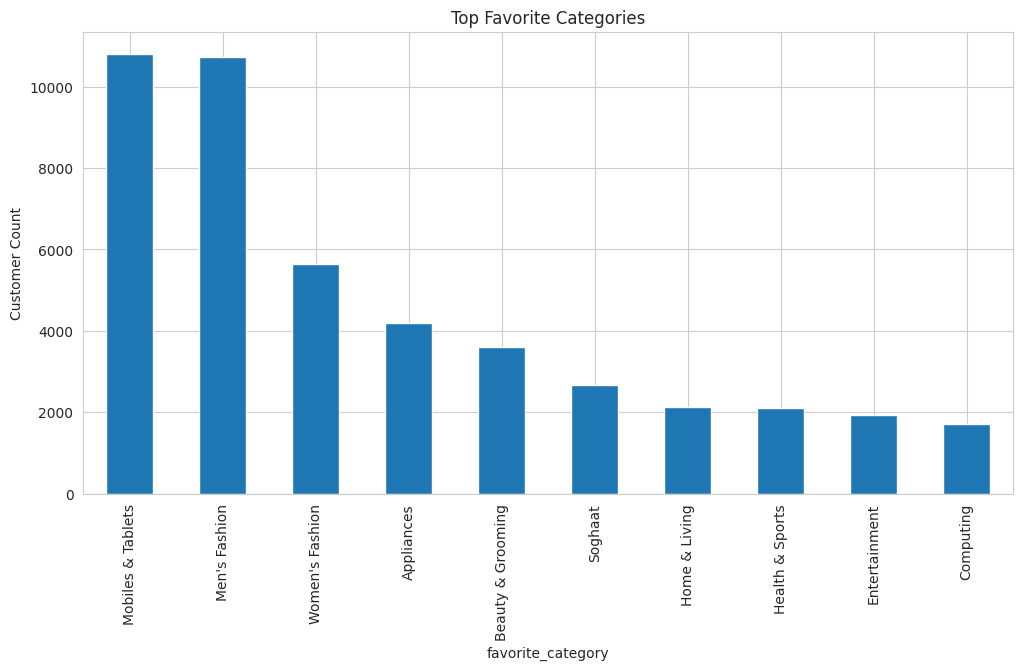

In [66]:
# ============================================
# GRAPH 18 — Favorite Categories
# ============================================

plt.figure(figsize=(12,6))

eda_df['favorite_category'] \
    .value_counts() \
    .head(10) \
    .plot(kind='bar')

plt.title("Top Favorite Categories")

plt.ylabel("Customer Count")

plt.show()

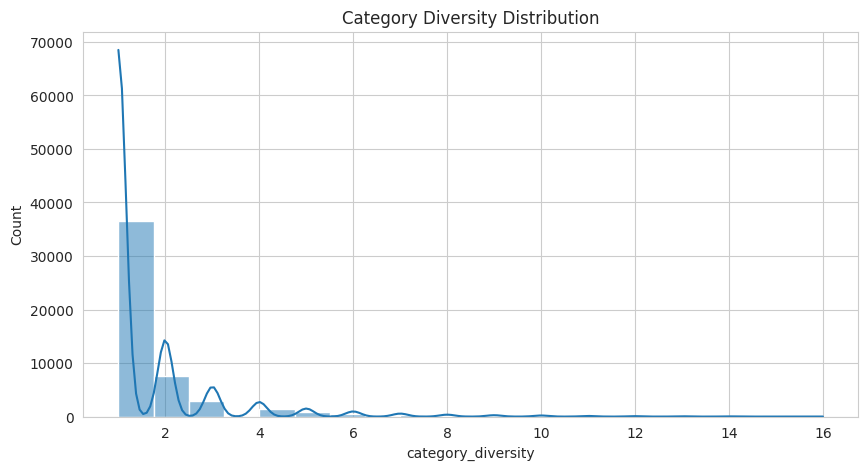

In [67]:
# ============================================
# GRAPH 19 — Category Diversity
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['category_diversity'],
    bins=20,
    kde=True
)

plt.title("Category Diversity Distribution")

plt.show()

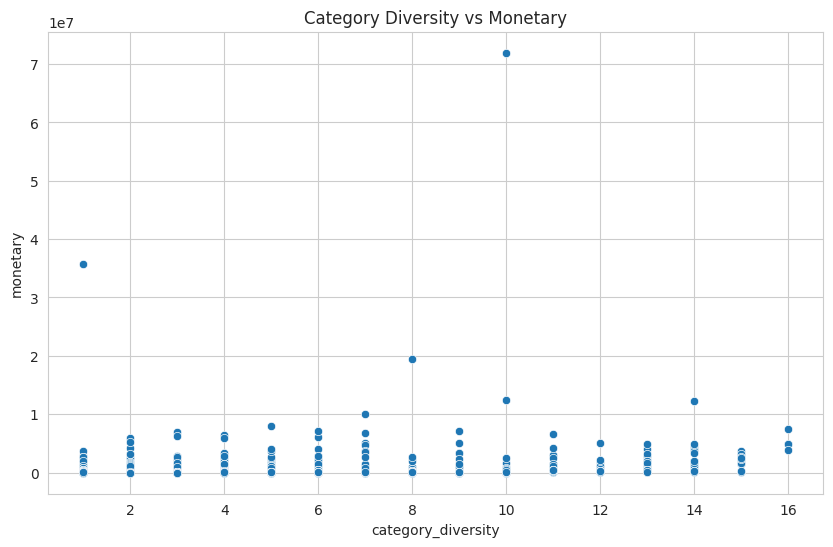

In [68]:
# ============================================
# GRAPH 20 — Diversity vs Monetary
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='category_diversity',
    y='monetary',
    data=eda_df
)

plt.title("Category Diversity vs Monetary")

plt.show()

# Time Based Analysis

In [69]:
# Create month column
data['month'] = data['created_at'].dt.to_period('M')

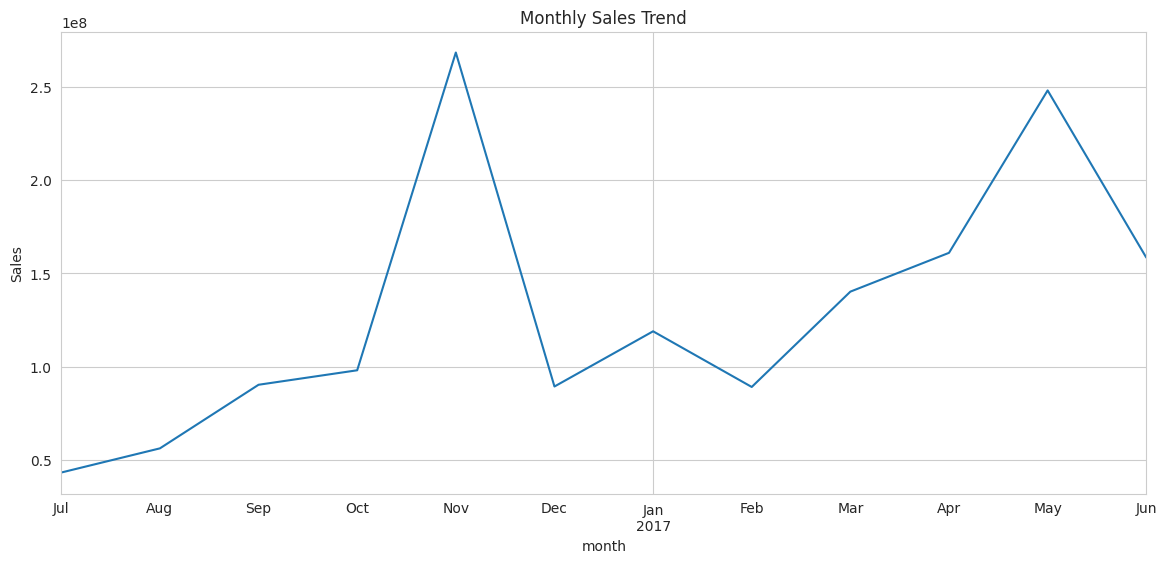

In [70]:
# ============================================
# GRAPH 21 — Monthly Sales Trend
# ============================================

monthly_sales = (
    data.groupby('month')['grand_total']
        .sum()
)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")

plt.show()

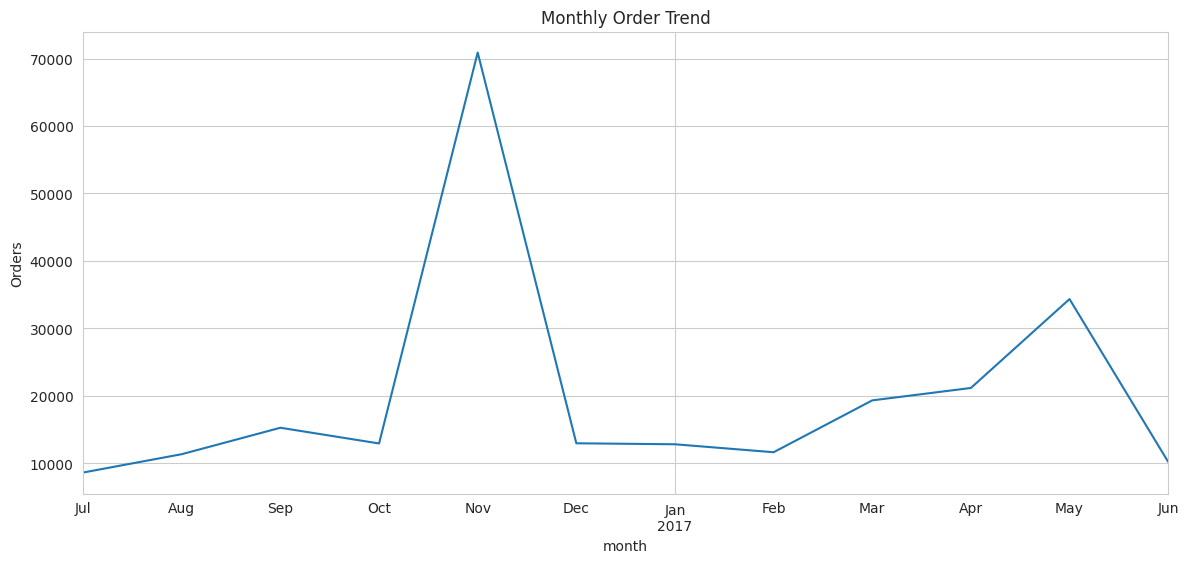

In [71]:
# ============================================
# GRAPH 22 — Monthly Order Trend
# ============================================

monthly_orders = (
    data.groupby('month')['customer_id']
        .count()
)

plt.figure(figsize=(14,6))

monthly_orders.plot()

plt.title("Monthly Order Trend")
plt.ylabel("Orders")

plt.show()

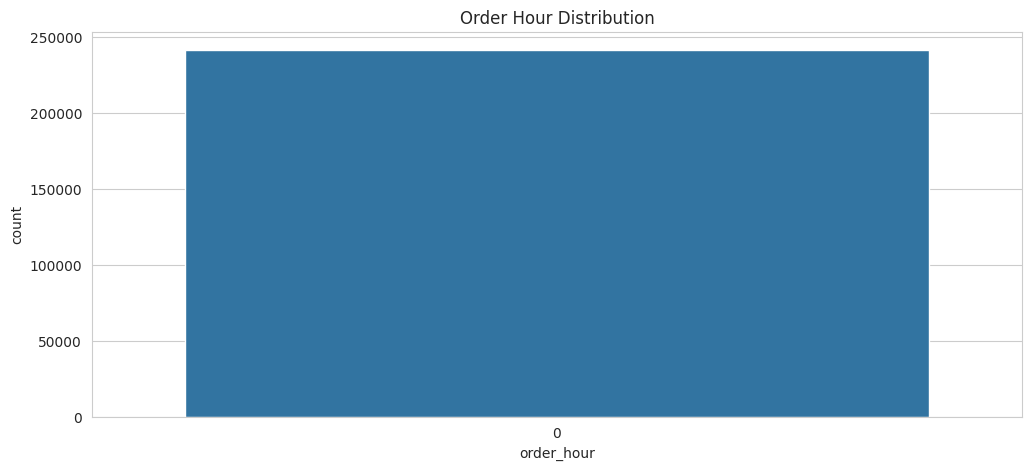

In [72]:
# ============================================
# GRAPH 23 — Order Hour Distribution
# ============================================

plt.figure(figsize=(12,5))

sns.countplot(
    x='order_hour',
    data=data
)

plt.title("Order Hour Distribution")

plt.show()

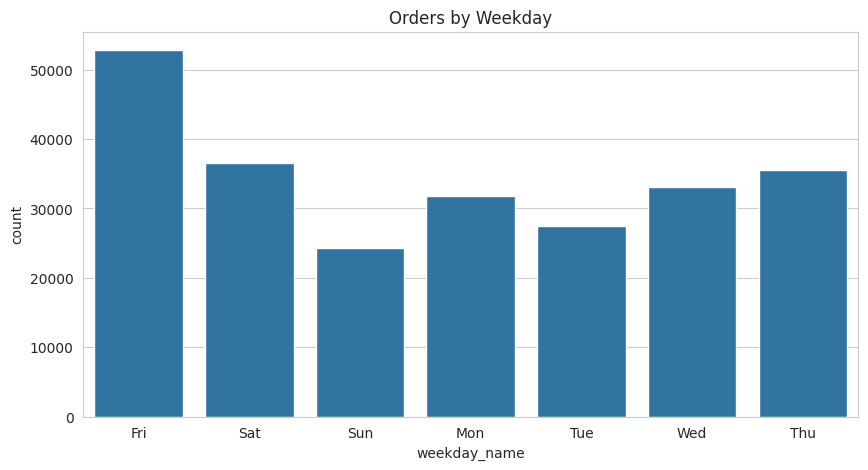

In [73]:
# ============================================
# GRAPH 24 — Weekday Distribution
# ============================================

weekday_map = {
    0:'Mon',
    1:'Tue',
    2:'Wed',
    3:'Thu',
    4:'Fri',
    5:'Sat',
    6:'Sun'
}

data['weekday_name'] = data['day_of_week'].map(
    weekday_map
)

plt.figure(figsize=(10,5))

sns.countplot(
    x='weekday_name',
    data=data
)

plt.title("Orders by Weekday")

plt.show()

# Behaviour Feature Analysis

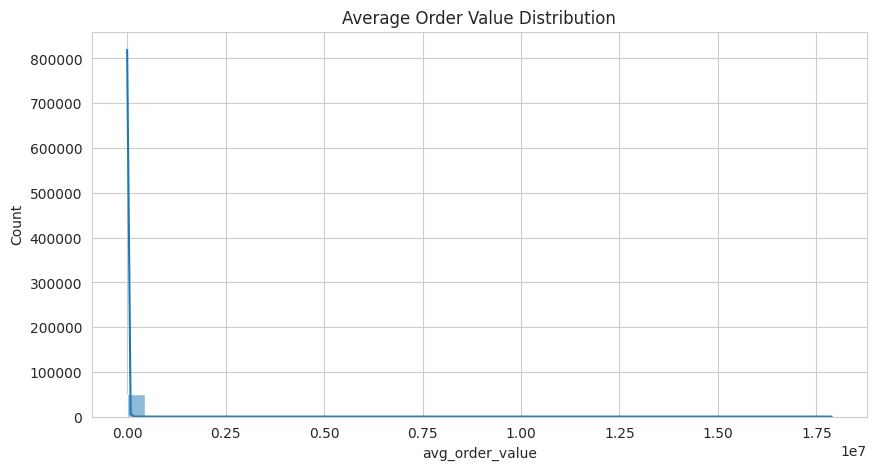

In [74]:
# ============================================
# GRAPH 25 — Average Order Value
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['avg_order_value'],
    bins=40,
    kde=True
)

plt.title("Average Order Value Distribution")

plt.show()

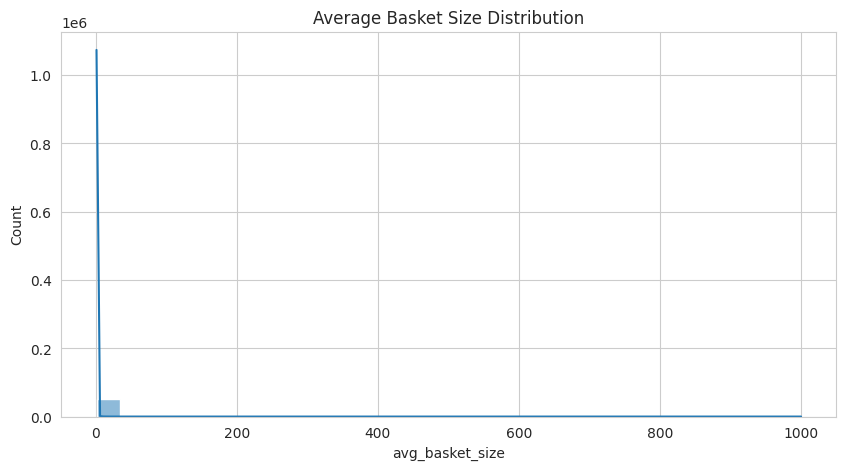

In [75]:
# ============================================
# GRAPH 26 — Basket Size Distribution
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['avg_basket_size'],
    bins=30,
    kde=True
)

plt.title("Average Basket Size Distribution")

plt.show()

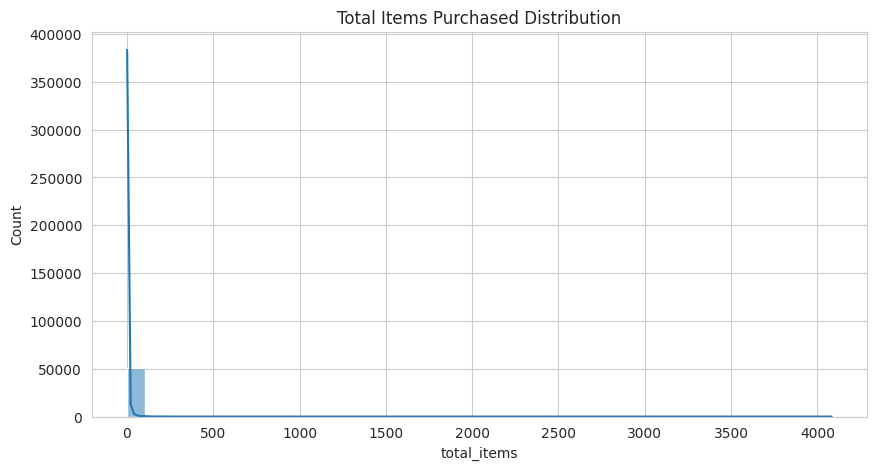

In [76]:
# ============================================
# GRAPH 27 — Total Items Purchased
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['total_items'],
    bins=40,
    kde=True
)

plt.title("Total Items Purchased Distribution")

plt.show()

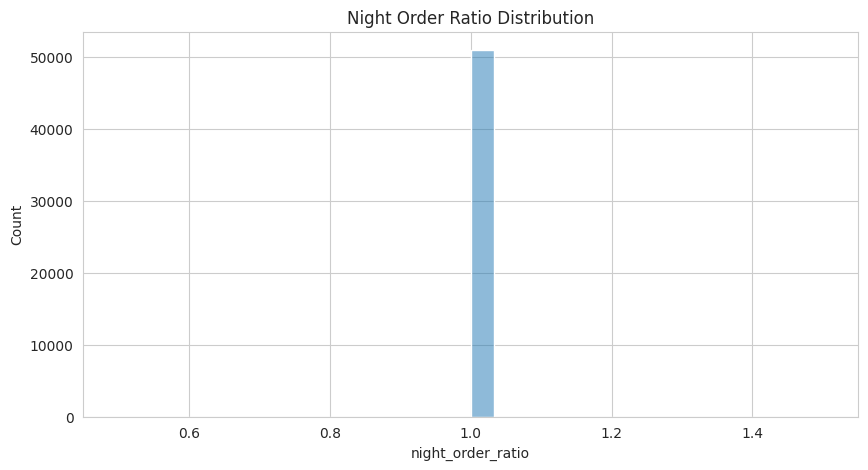

In [77]:
# ============================================
# GRAPH 28 — Night Order Ratio
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    eda_df['night_order_ratio'],
    bins=30,
    kde=True
)

plt.title("Night Order Ratio Distribution")

plt.show()

# Correlation Analysis

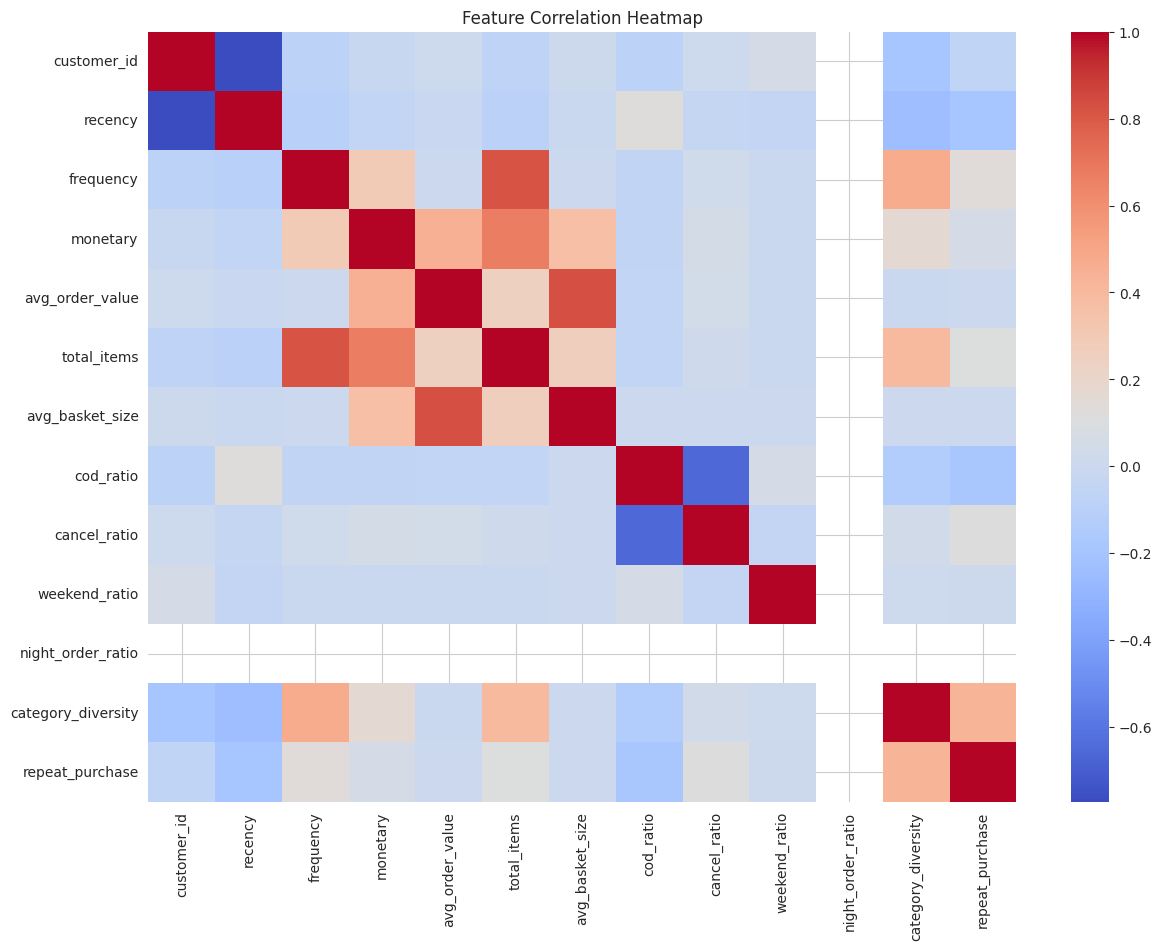

In [78]:
# ============================================
# GRAPH 29 — Full Correlation Heatmap
# ============================================

numerical_features = eda_df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numerical_features.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Target Variable Analysis

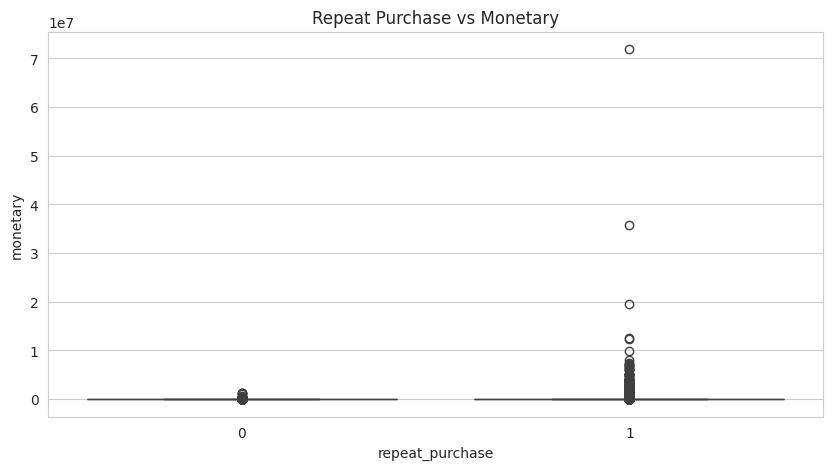

In [79]:
# ============================================
# GRAPH 30 — Repeat Purchase vs Monetary
# ============================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x='repeat_purchase',
    y='monetary',
    data=eda_df
)

plt.title("Repeat Purchase vs Monetary")

plt.show()

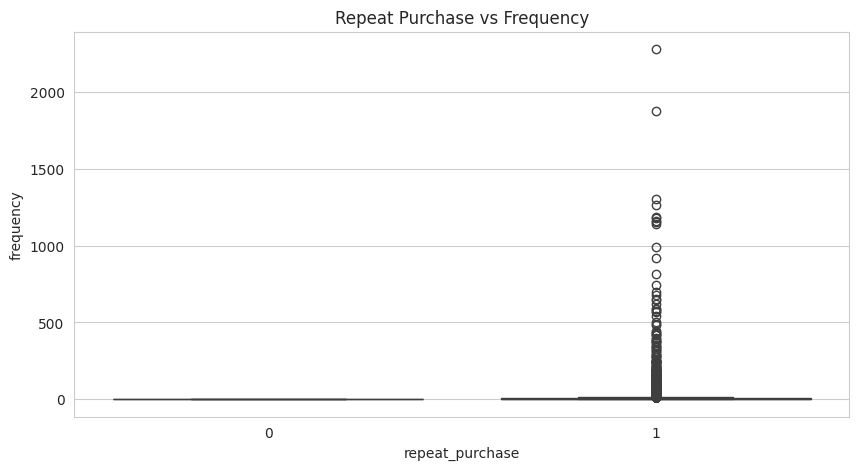

In [80]:
# ============================================
# GRAPH 31 — Repeat Purchase vs Frequency
# ============================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x='repeat_purchase',
    y='frequency',
    data=eda_df
)

plt.title("Repeat Purchase vs Frequency")

plt.show()

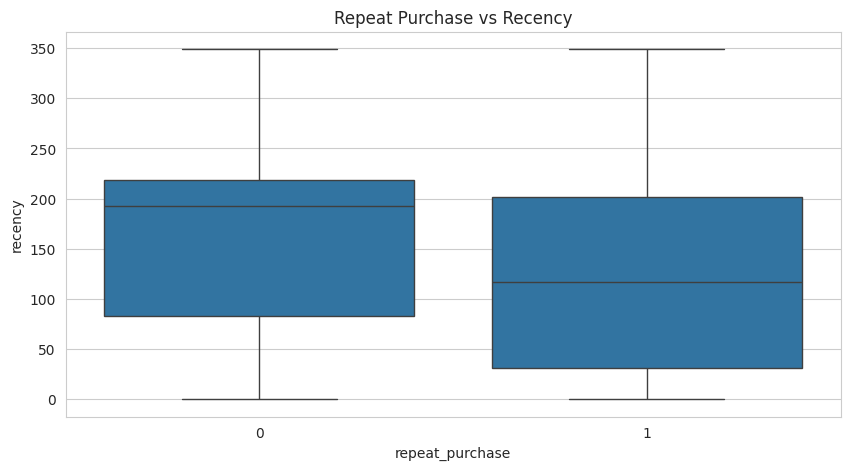

In [81]:
# ============================================
# GRAPH 32 — Repeat Purchase vs Recency
# ============================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x='repeat_purchase',
    y='recency',
    data=eda_df
)

plt.title("Repeat Purchase vs Recency")

plt.show()

# Creating Customer Segmentation Dataset

In [82]:
# ============================================
# SECTION 7 — CUSTOMER SEGMENTATION
# ============================================

# Features for clustering
cluster_features = eda_df[[
    'recency',
    'frequency',
    'monetary',
    'avg_order_value',
    'total_items',
    'avg_basket_size',
    'cod_ratio',
    'cancel_ratio',
    'weekend_ratio',
    'night_order_ratio',
    'category_diversity'
]]

In [83]:
# Display shape
cluster_features.shape

(50969, 11)

# Feature Scaling

monetary = huge values

frequency = small values

In [84]:
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

# Finding Optimal Number of Clusters Using Elbow Method

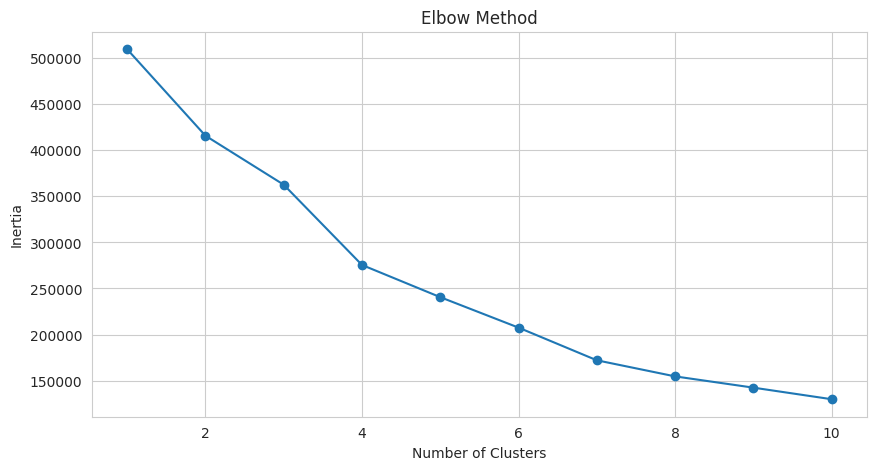

In [85]:
# ============================================
# GRAPH 33 — Elbow Method
# ============================================

inertia = []

k_values = range(1, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10,5))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [86]:
# ============================================
# FINAL KMEANS MODEL
# ============================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

cluster_labels = kmeans.fit_predict(
    scaled_features
)

In [87]:
# Add cluster labels
eda_df['cluster'] = cluster_labels

In [88]:
# Cluster counts
eda_df['cluster'].value_counts()

,count
cluster,
1,32551
0,18380
2,37
3,1


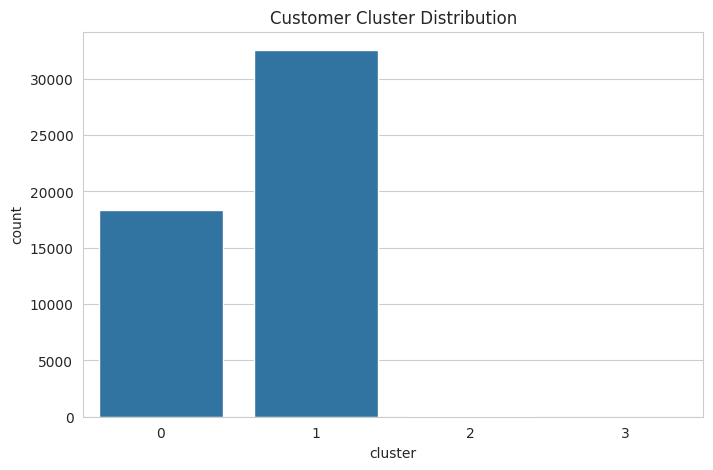

In [89]:
# ============================================
# GRAPH 34 — Cluster Distribution
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='cluster',
    data=eda_df
)

plt.title("Customer Cluster Distribution")

plt.show()

# PCA For Cluster Visualization

In [90]:
# ============================================
# PCA DIMENSION REDUCTION
# ============================================

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

# Create PCA dataframe
pca_df = pd.DataFrame(
    pca_features,
    columns=['PCA1', 'PCA2']
)

# Add cluster labels
pca_df['cluster'] = cluster_labels

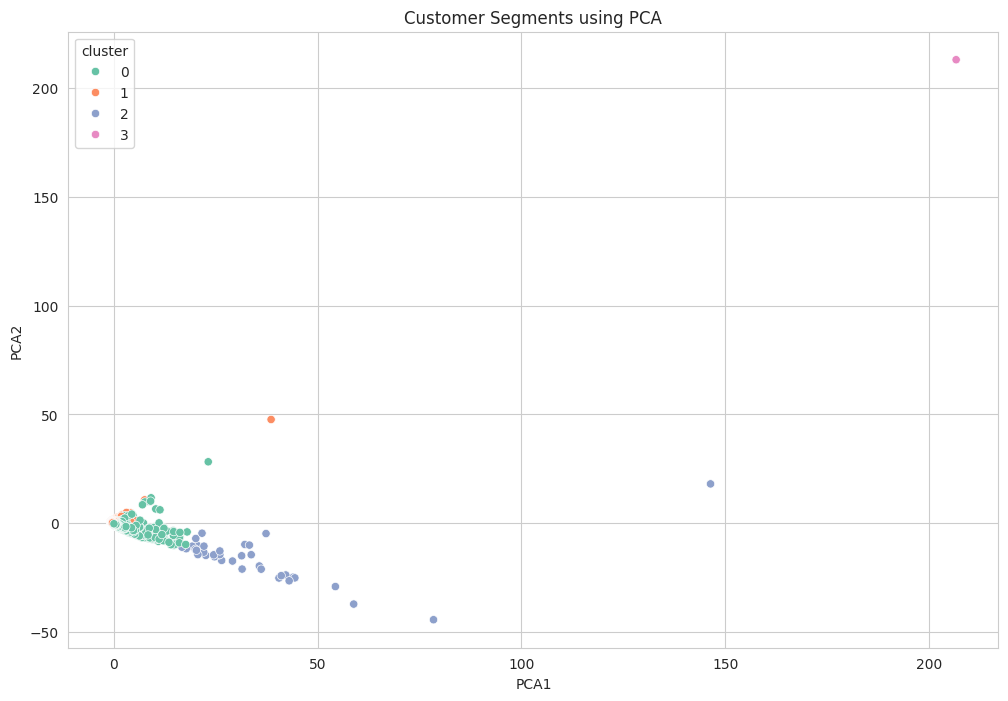

In [91]:
# ============================================
# GRAPH 35 — PCA Cluster Visualization
# ============================================

plt.figure(figsize=(12,8))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='cluster',
    data=pca_df,
    palette='Set2'
)

plt.title("Customer Segments using PCA")

plt.show()

# Creating Cluster Profiles

In [92]:
# ============================================
# CLUSTER PROFILE ANALYSIS
# ============================================

cluster_profile = eda_df.groupby('cluster')[[
    'recency',
    'frequency',
    'monetary',
    'avg_order_value',
    'cod_ratio',
    'cancel_ratio'
]].mean()

cluster_profile

,recency,frequency,monetary,avg_order_value,cod_ratio,cancel_ratio
cluster,,,,,,
0,130.193145,7.067084,5.579013e+04,1.021595e+04,0.204326,0.645389
1,152.540782,2.583945,8.779405e+03,3.427897e+03,0.984806,0.027784
2,26.945946,744.351351,5.792739e+06,4.294358e+04,0.663133,0.227381
3,6.000000,2.000000,3.577600e+07,1.788800e+07,0.000000,0.000000


In [93]:
# ============================================
# ASSIGN SEGMENT NAMES
# ============================================

segment_map = {
    0: 'Premium Loyalists',
    1: 'Discount Hunters',
    2: 'Casual Buyers',
    3: 'At-Risk Customers'
}

eda_df['segment_name'] = (
    eda_df['cluster']
        .map(segment_map)
)

In [94]:
# Segment counts
eda_df['segment_name'].value_counts()

,count
segment_name,
Discount Hunters,32551
Premium Loyalists,18380
Casual Buyers,37
At-Risk Customers,1


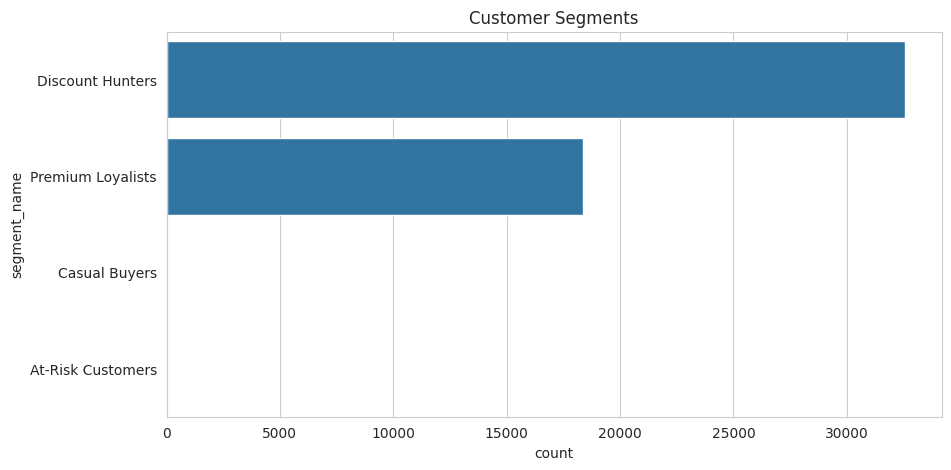

In [95]:
# ============================================
# GRAPH 36 — Segment Distribution
# ============================================

plt.figure(figsize=(10,5))

sns.countplot(
    y='segment_name',
    data=eda_df,
    order=eda_df['segment_name']
            .value_counts()
            .index
)

plt.title("Customer Segments")

plt.show()

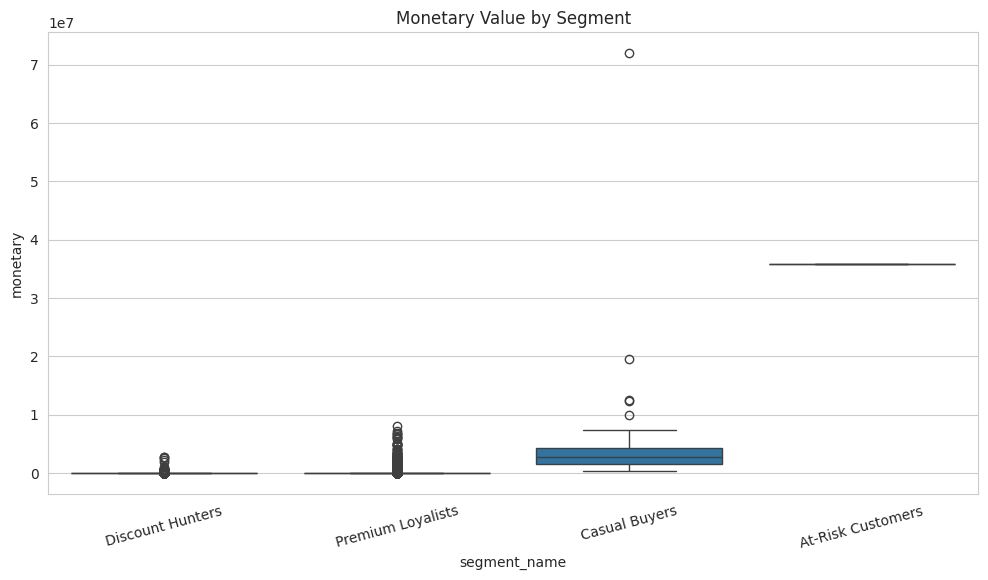

In [96]:
# ============================================
# GRAPH 37 — Monetary by Segment
# ============================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='segment_name',
    y='monetary',
    data=eda_df
)

plt.xticks(rotation=15)

plt.title("Monetary Value by Segment")

plt.show()

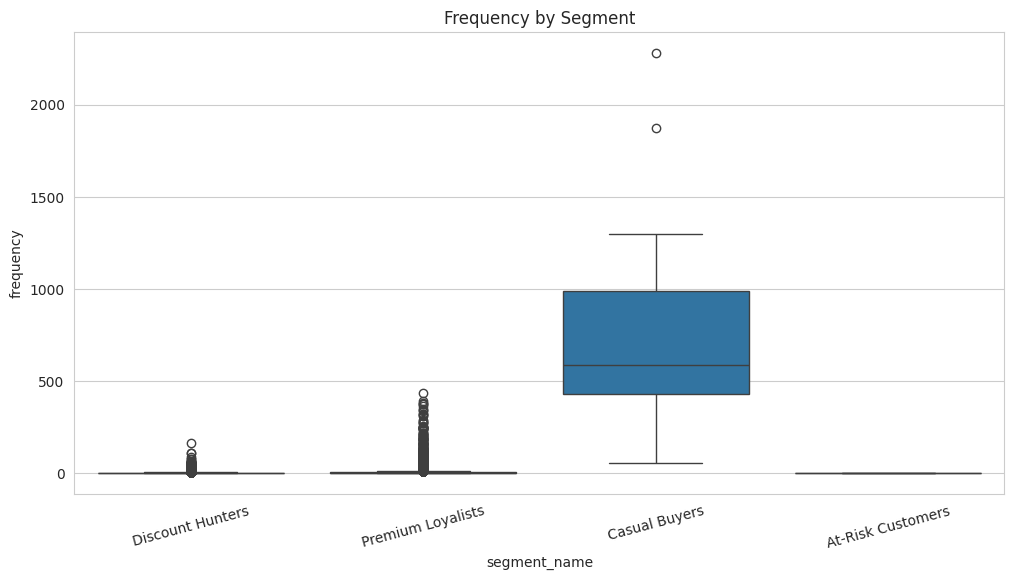

In [97]:
# ============================================
# GRAPH 38 — Frequency by Segment
# ============================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='segment_name',
    y='frequency',
    data=eda_df
)

plt.xticks(rotation=15)

plt.title("Frequency by Segment")

plt.show()

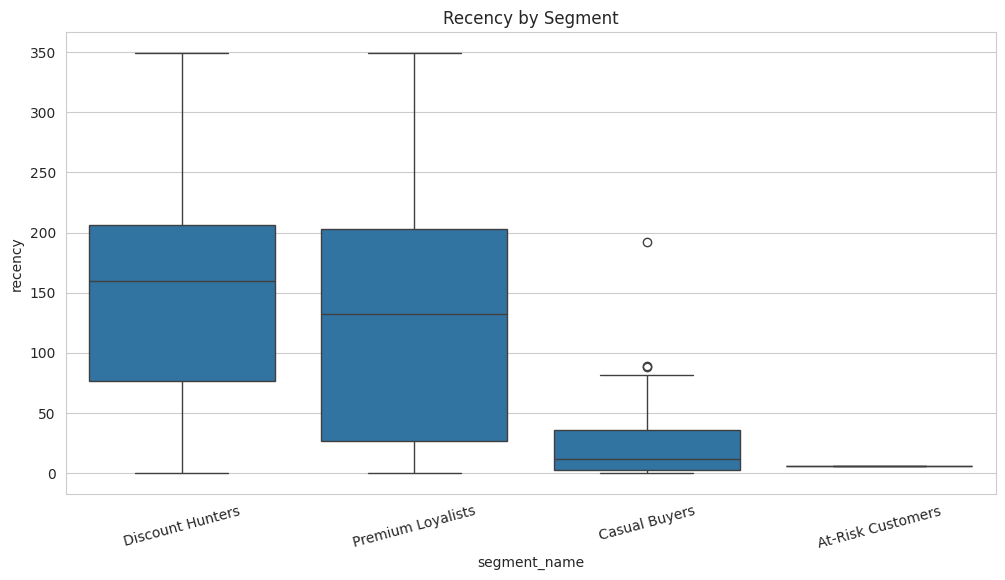

In [98]:
# ============================================
# GRAPH 39 — Recency by Segment
# ============================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='segment_name',
    y='recency',
    data=eda_df
)

plt.xticks(rotation=15)

plt.title("Recency by Segment")

plt.show()

In [99]:
# Save final segmented dataset
eda_df.to_csv(
    "segmented_customer_dataset.csv",
    index=False
)

# Repeat Purchase Prediction

In [100]:
# ============================================
# SECTION 8 — PREDICTION MODELING
# ============================================

model_df = eda_df.copy()

In [101]:
# Features for prediction
features = [

    'recency',
    'frequency',
    'monetary',

    'avg_order_value',
    'total_items',
    'avg_basket_size',

    'cod_ratio',
    'cancel_ratio',

    'weekend_ratio',
    'night_order_ratio',

    'category_diversity',

    'cluster'
]

In [102]:
# Feature matrix
X = model_df[features]

# Target variable
y = model_df['repeat_purchase']

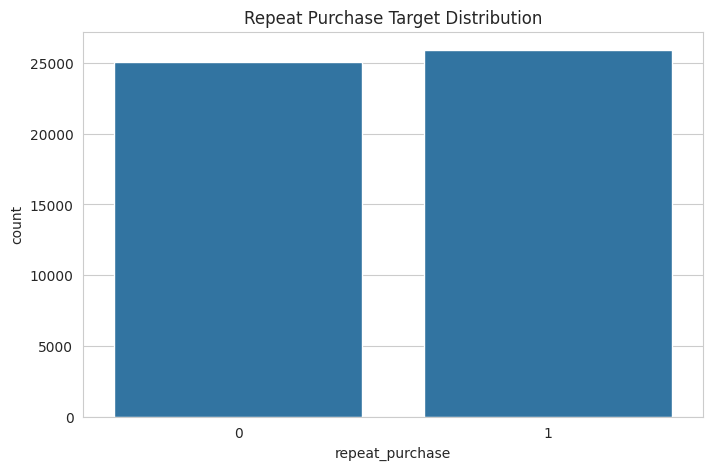

In [103]:
# ============================================
# GRAPH 40 — Target Variable Distribution
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(x=y)

plt.title("Repeat Purchase Target Distribution")

plt.show()

In [104]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (40775, 12)
Testing Shape: (10194, 12)


In [105]:
# ============================================
# LOGISTIC REGRESSION
# ============================================

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

# Predictions
lr_model = LogisticRegression(
    C=0.05,
    penalty='l2',
    solver='liblinear',
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Probabilities
lr_probs = lr_model.predict_proba(X_test)[:,1]

In [106]:
# ============================================
# LOGISTIC REGRESSION EVALUATION
# ============================================

print("Logistic Regression Results\n")

print("Accuracy:",
      accuracy_score(y_test, lr_preds))

print("Precision:",
      precision_score(y_test, lr_preds))

print("Recall:",
      recall_score(y_test, lr_preds))

print("F1 Score:",
      f1_score(y_test, lr_preds))

print("ROC AUC:",
      roc_auc_score(y_test, lr_probs))

Logistic Regression Results

Accuracy: 0.9980380616048656
Precision: 1.0
Recall: 0.9961434631700733
F1 Score: 0.9980680061823802
ROC AUC: 0.999989950518045


In [107]:
# ============================================
# RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Probabilities
rf_probs = rf_model.predict_proba(X_test)[:,1]

In [108]:
# ============================================
# RANDOM FOREST EVALUATION
# ============================================

print("Random Forest Results\n")

print("Accuracy:",
      accuracy_score(y_test, rf_preds))

print("Precision:",
      precision_score(y_test, rf_preds))

print("Recall:",
      recall_score(y_test, rf_preds))

print("F1 Score:",
      f1_score(y_test, rf_preds))

print("ROC AUC:",
      roc_auc_score(y_test, rf_probs))

Random Forest Results

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0


# Final Model XGBoost

In [109]:
# ============================================
# XGBOOST MODEL
# ============================================

xgb_model = XGBClassifier(
    n_estimators=15,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_preds = xgb_model.predict(X_test)

# Probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

In [110]:
# ============================================
# XGBOOST EVALUATION
# ============================================

print("XGBoost Results\n")

print("Accuracy:",
      accuracy_score(y_test, xgb_preds))

print("Precision:",
      precision_score(y_test, xgb_preds))

print("Recall:",
      recall_score(y_test, xgb_preds))

print("F1 Score:",
      f1_score(y_test, xgb_preds))

print("ROC AUC:",
      roc_auc_score(y_test, xgb_probs))

XGBoost Results

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0


# Model Comparison Table

In [111]:
# ============================================
# MODEL COMPARISON
# ============================================

results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],

    'F1 Score': [
        f1_score(y_test, lr_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, xgb_preds)
    ],

    'ROC AUC': [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

results

,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.998038,0.998068,0.99999
1,Random Forest,1.000000,1.000000,1.00000
2,XGBoost,1.000000,1.000000,1.00000


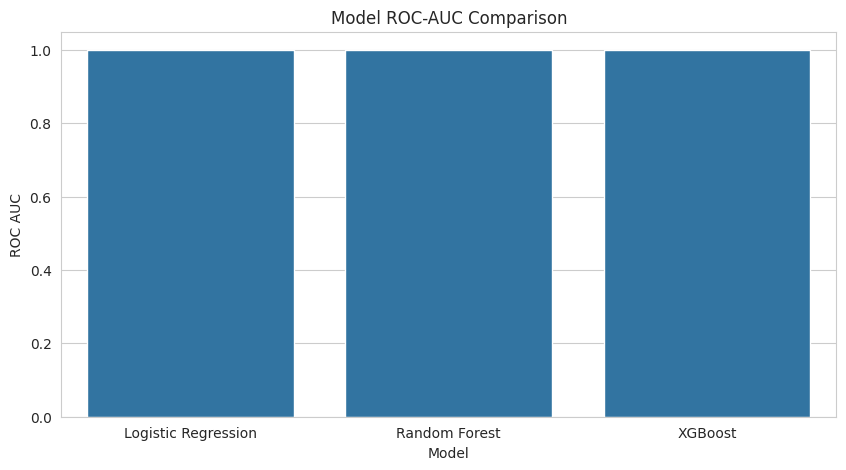

In [112]:
# ============================================
# GRAPH 41 — Model Comparison
# ============================================

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='ROC AUC',
    data=results
)

plt.title("Model ROC-AUC Comparison")

plt.show()

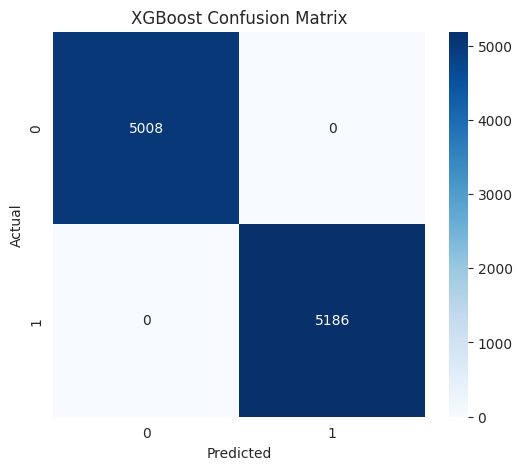

In [113]:
# ============================================
# GRAPH 42 — Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test,
    xgb_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

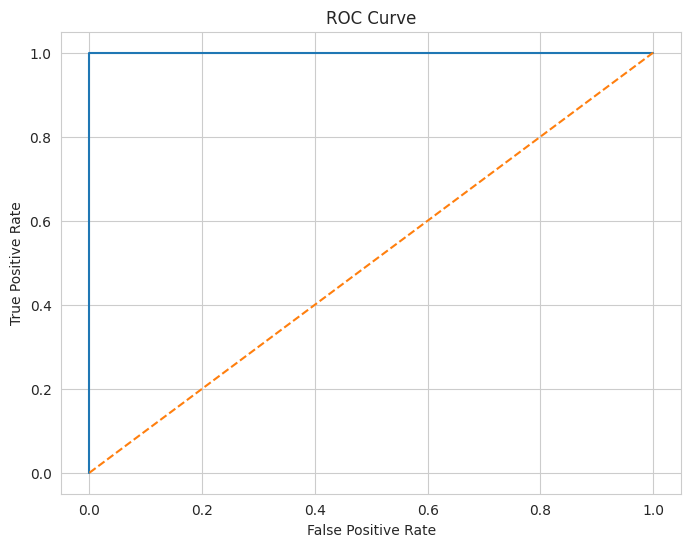

In [114]:
# ============================================
# GRAPH 43 — ROC Curve
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    xgb_probs
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

# Feature Importance

In [115]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

importance_df = pd.DataFrame({

    'Feature': features,
    'Importance': xgb_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head()

,Feature,Importance
1,frequency,1.0
0,recency,0.0
2,monetary,0.0
3,avg_order_value,0.0
4,total_items,0.0


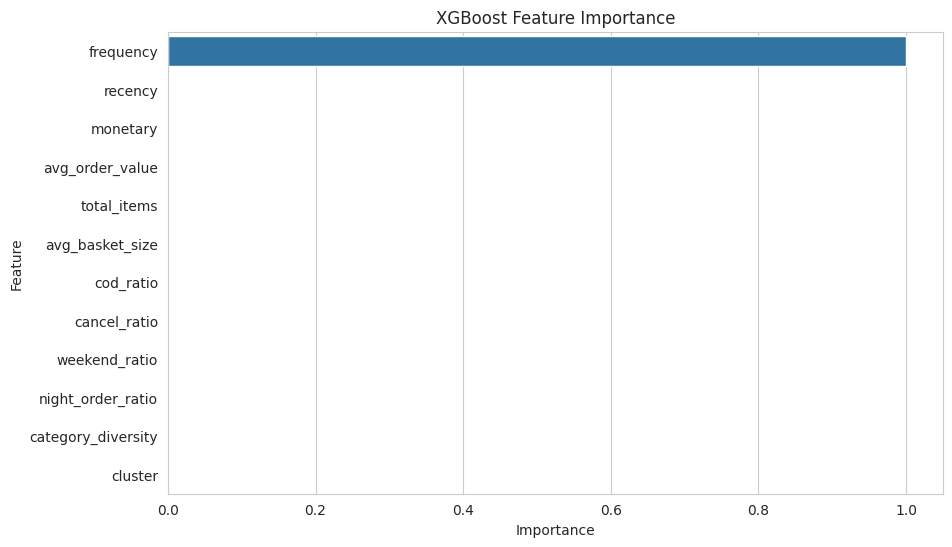

In [116]:
# ============================================
# GRAPH 44 — Feature Importance
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("XGBoost Feature Importance")

plt.show()

# Explainablity AI

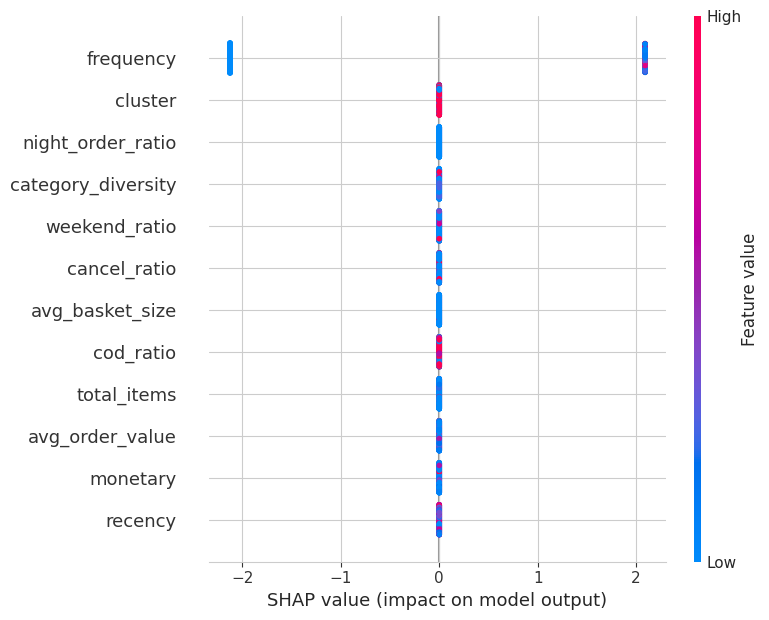

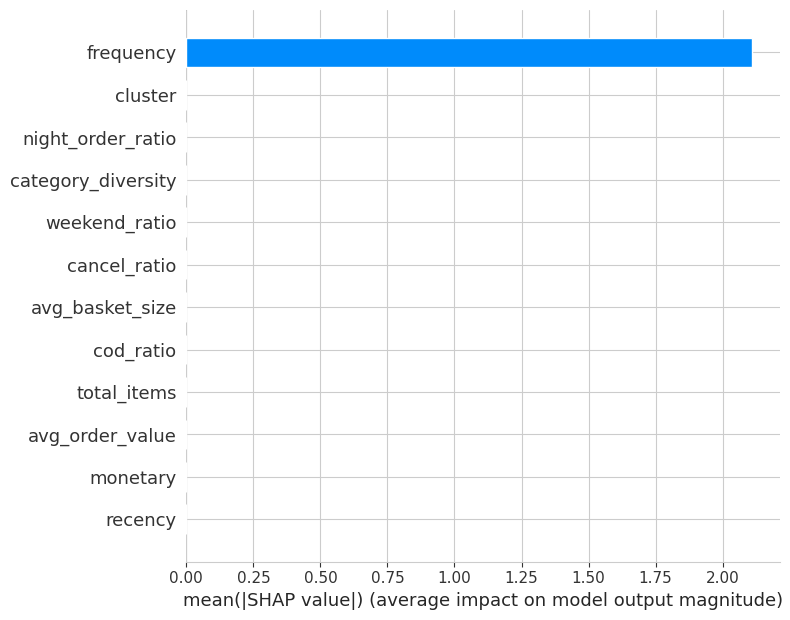

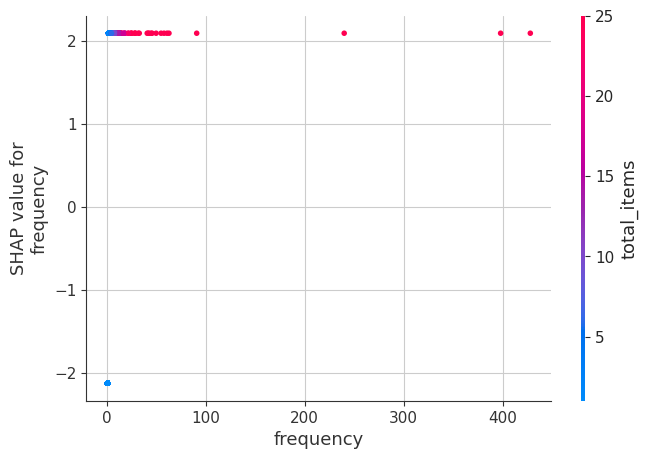

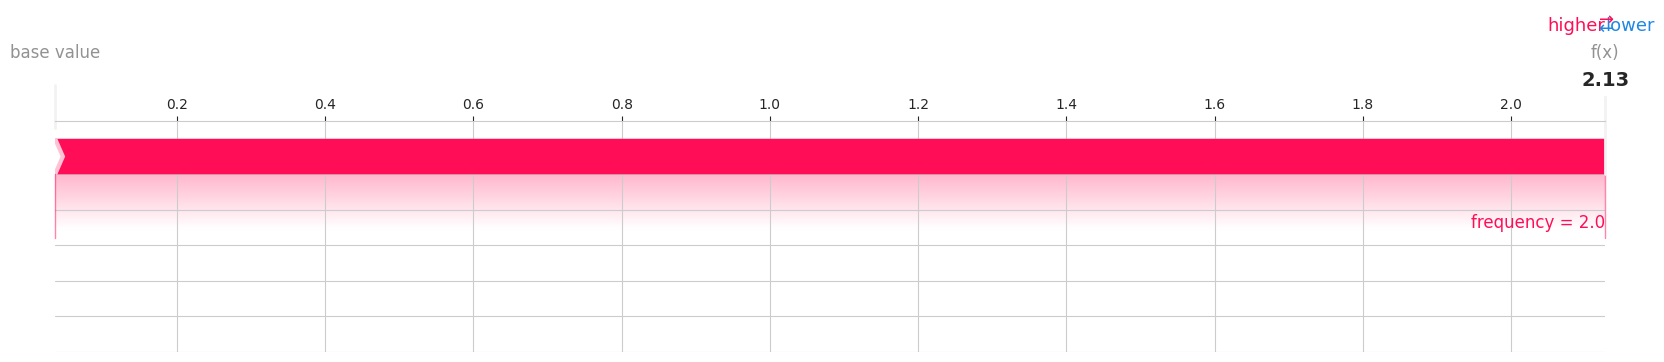

In [117]:
# ============================================
# SECTION 9 — SHAP EXPLAINABILITY
# ============================================

import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(
    xgb_model
)

# Sample for speed
X_sample = X_test.sample(
    min(500, len(X_test)),
    random_state=42
)

# Generate SHAP values
shap_values = explainer.shap_values(
    X_sample
)

# ============================================
# GRAPH 45 — SHAP SUMMARY
# ============================================

shap.summary_plot(
    shap_values,
    X_sample
)

# ============================================
# GRAPH 46 — SHAP BARPLOT
# ============================================

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar'
)

# ============================================
# GRAPH 47 — DEPENDENCE PLOT
# ============================================

shap.dependence_plot(
    'frequency',
    shap_values,
    X_sample
)

# ============================================
# GRAPH 48 — LOCAL EXPLANATION
# ============================================

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0],
    matplotlib=True
)

In [118]:
# Generate SHAP values
shap_values = explainer.shap_values(
    X_test
)

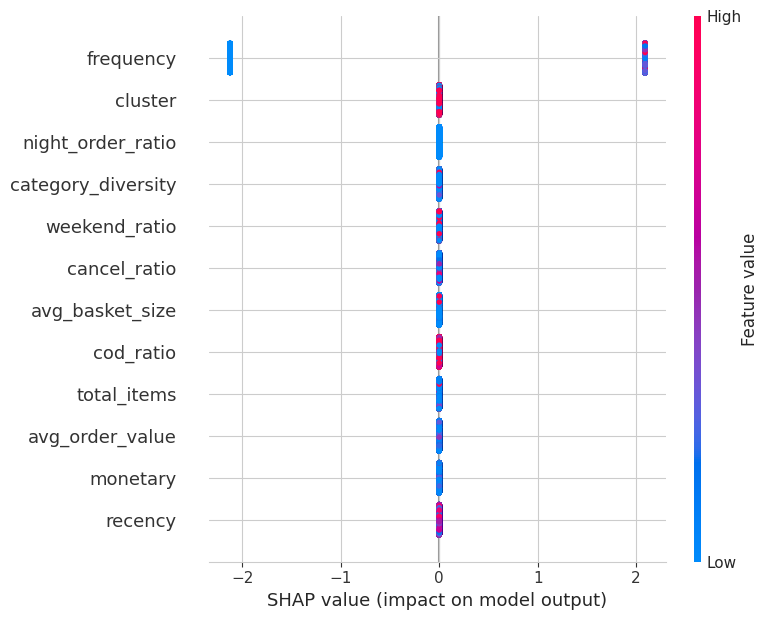

In [119]:
# ============================================
# GRAPH 45 — SHAP Summary Plot
# ============================================

shap.summary_plot(
    shap_values,
    X_test
)

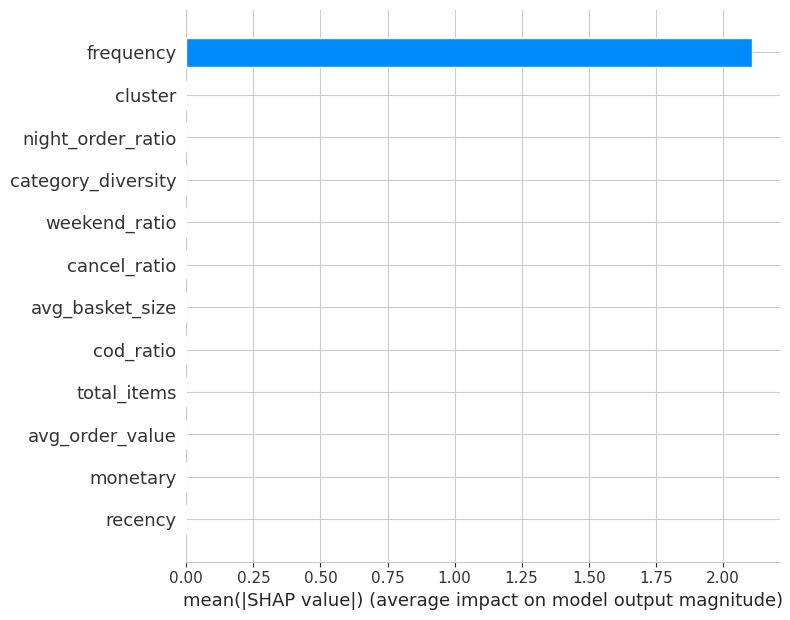

In [120]:
# ============================================
# GRAPH 46 — SHAP Feature Importance
# ============================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

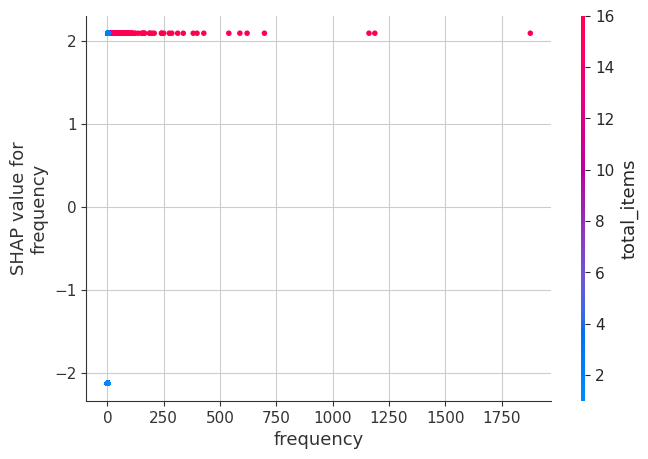

In [121]:
# ============================================
# GRAPH 47 — SHAP Dependence Plot
# ============================================

shap.dependence_plot(
    'frequency',
    shap_values,
    X_test
)

In [122]:
# Select one customer
sample_index = 0

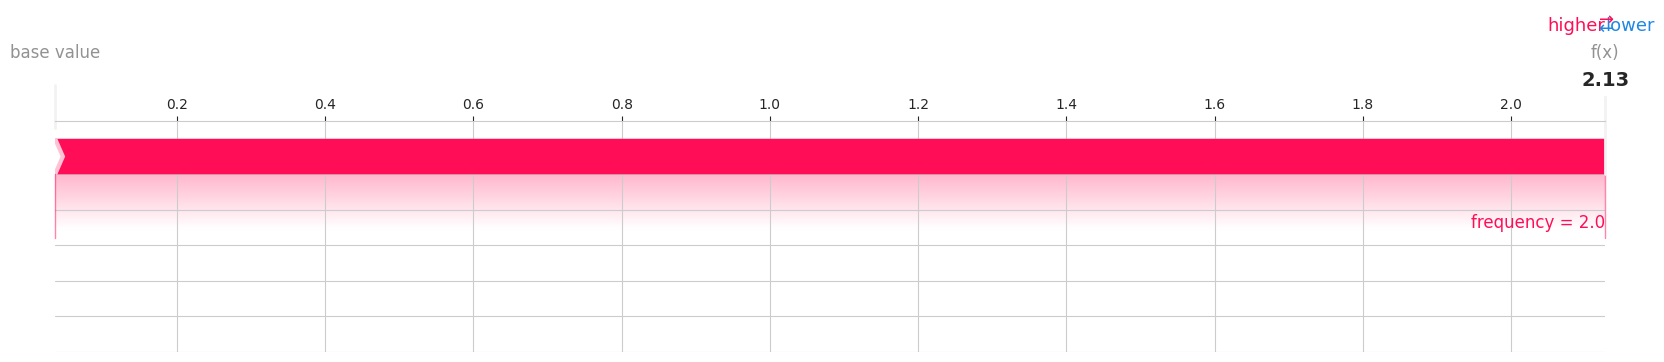

In [123]:
# ============================================
# GRAPH 48 — Individual Prediction Explanation
# ============================================

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

# Last Business Intelligence Layer

In [124]:
# ============================================
# SECTION 10 — BUSINESS RECOMMENDATIONS
# ============================================

# Predict probabilities for all customers
model_df['repeat_probability'] = (
    xgb_model.predict_proba(X)[:,1]
)

In [125]:
# Display probabilities
model_df[
    ['customer_id', 'repeat_probability']
].head()

,customer_id,repeat_probability
0,1.0,0.110108
1,2.0,0.893473
2,3.0,0.893473
3,4.0,0.893473
4,5.0,0.110108


# Creating Risk Categories

In [127]:
 # ============================================
# CUSTOMER RISK SEGMENTS
# ============================================

conditions = [

    model_df['repeat_probability'] >= 0.75,

    (
        (model_df['repeat_probability'] >= 0.40) &
        (model_df['repeat_probability'] < 0.75)
    ),

    model_df['repeat_probability'] < 0.40
]

labels = [
    'High Retention',
    'Medium Retention',
    'At Risk'
]

model_df['retention_segment'] = np.select(
    conditions,
    labels,
    default='Unknown'
)

In [128]:
# Retention segment counts
model_df['retention_segment'].value_counts()

,count
retention_segment,
High Retention,25927
At Risk,25042


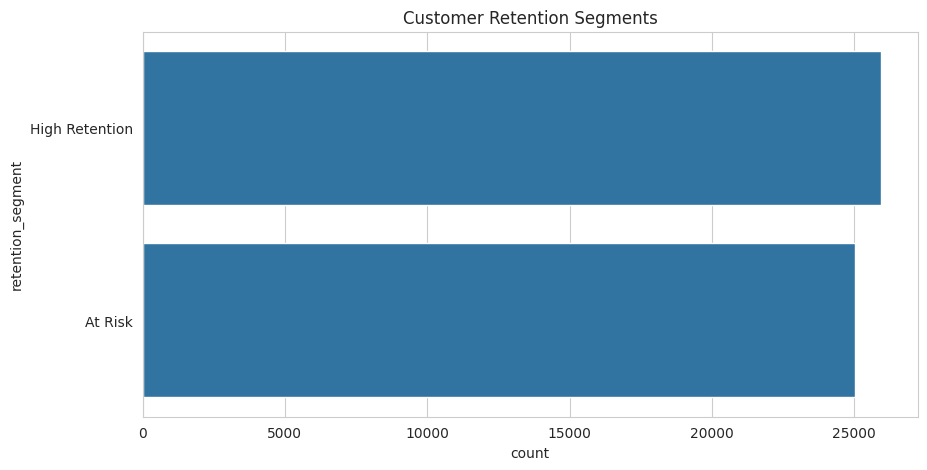

In [129]:
# ============================================
# GRAPH 49 — Retention Segments
# ============================================

plt.figure(figsize=(10,5))

sns.countplot(
    y='retention_segment',
    data=model_df,
    order=model_df['retention_segment']
            .value_counts()
            .index
)

plt.title("Customer Retention Segments")

plt.show()

In [130]:
# ============================================
# RECOMMENDATION ENGINE
# ============================================

def generate_recommendation(row):

    if row['retention_segment'] == 'High Retention':

        return (
            "Provide loyalty rewards and premium offers"
        )

    elif row['retention_segment'] == 'Medium Retention':

        return (
            "Send personalized discounts and reminders"
        )

    else:

        return (
            "Run reactivation campaigns and verify COD orders"
        )

In [131]:
# Generate recommendations
model_df['business_action'] = model_df.apply(
    generate_recommendation,
    axis=1
)

In [132]:
# Sample recommendations
model_df[
    [
        'customer_id',
        'retention_segment',
        'business_action'
    ]
].head()

,customer_id,retention_segment,business_action
0,1.0,At Risk,Run reactivation campaigns and verify COD orders
1,2.0,High Retention,Provide loyalty rewards and premium offers
2,3.0,High Retention,Provide loyalty rewards and premium offers
3,4.0,High Retention,Provide loyalty rewards and premium offers
4,5.0,At Risk,Run reactivation campaigns and verify COD orders


In [133]:
# ============================================
# CUSTOMER VALUE TIERS
# ============================================

model_df['value_tier'] = pd.qcut(

    model_df['monetary'],

    q=4,

    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Premium Value'
    ]
)

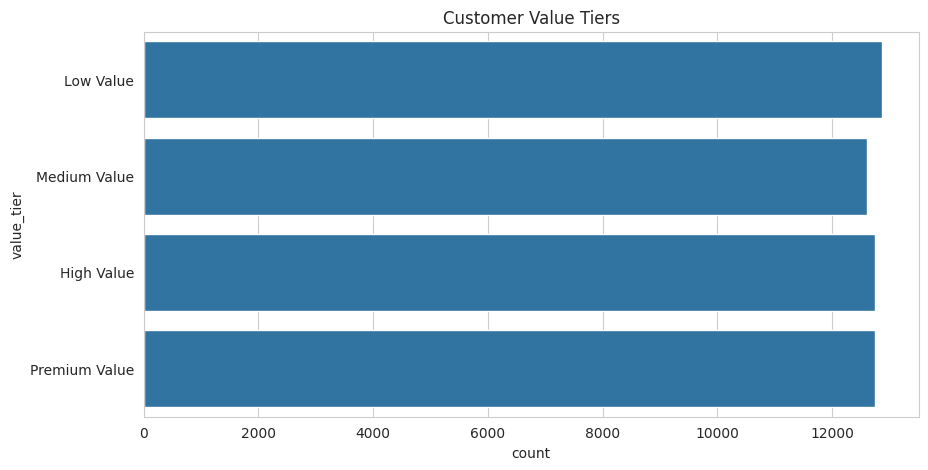

In [134]:
# ============================================
# GRAPH 50 — Customer Value Tiers
# ============================================

plt.figure(figsize=(10,5))

sns.countplot(
    y='value_tier',
    data=model_df
)

plt.title("Customer Value Tiers")

plt.show()

In [135]:
# ============================================
# HIGH VALUE AT-RISK CUSTOMERS
# ============================================

high_risk_customers = model_df[

    (model_df['value_tier'].isin([
        'High Value',
        'Premium Value'
    ]))

    &

    (model_df['retention_segment'] == 'At Risk')
]

In [136]:
# Display high-risk customers
high_risk_customers[
    [
        'customer_id',
        'monetary',
        'repeat_probability',
        'retention_segment'
    ]
].head()

,customer_id,monetary,repeat_probability,retention_segment
8,9.0,5500.0,0.110108,At Risk
17,18.0,3000.0,0.110108,At Risk
25,26.0,4500.0,0.110108,At Risk
88,90.0,3290.0,0.110108,At Risk
102,104.0,3250.0,0.110108,At Risk


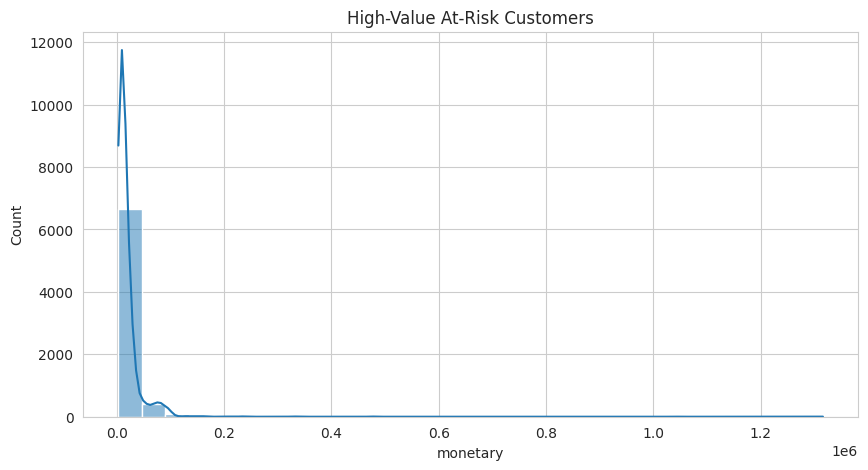

In [137]:
# ============================================
# GRAPH 51 — High Risk Customers
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    high_risk_customers['monetary'],
    bins=30,
    kde=True
)

plt.title("High-Value At-Risk Customers")

plt.show()

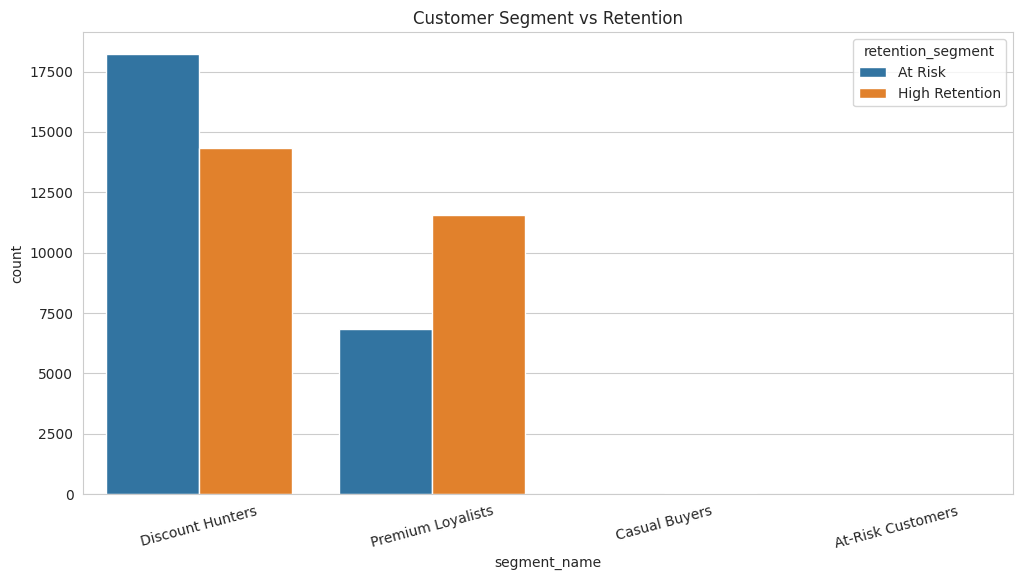

In [138]:
# ============================================
# GRAPH 52 — Segment vs Retention
# ============================================

plt.figure(figsize=(12,6))

sns.countplot(
    x='segment_name',
    hue='retention_segment',
    data=model_df
)

plt.xticks(rotation=15)

plt.title("Customer Segment vs Retention")

plt.show()

# Final Output

In [139]:
# ============================================
# FINAL BUSINESS INTELLIGENCE DATASET
# ============================================

final_output = model_df[[
    'customer_id',

    'segment_name',

    'retention_segment',

    'repeat_probability',

    'value_tier',

    'business_action',

    'monetary',

    'frequency',

    'recency'
]]

In [140]:
# Display final output
final_output.head()

,customer_id,segment_name,retention_segment,repeat_probability,value_tier,business_action,monetary,frequency,recency
0,1.0,Discount Hunters,At Risk,0.110108,Medium Value,Run reactivation campaigns and verify COD orders,1950.00,1,349
1,2.0,Premium Loyalists,High Retention,0.893473,Low Value,Provide loyalty rewards and premium offers,510.00,2,202
2,3.0,Discount Hunters,High Retention,0.893473,High Value,Provide loyalty rewards and premium offers,7430.00,5,27
3,4.0,Premium Loyalists,High Retention,0.893473,Premium Value,Provide loyalty rewards and premium offers,2122790.55,381,9
4,5.0,Discount Hunters,At Risk,0.110108,Medium Value,Run reactivation campaigns and verify COD orders,1110.00,1,349


In [141]:
# Save final dataset
final_output.to_csv(
    "business_recommendation_output.csv",
    index=False
)